# Adaptive Fraud Detection with Dynamic Thresholding and Cost-Sensitive Learning

**EE559 (CSCI 559) — Final Project Report** 
**Student:** Om Suresh Prajapati &nbsp;|&nbsp; **USC ID:** 1430823821 &nbsp;|&nbsp; **Date:** May 4, 2026

---

> **Abstract:** This notebook presents the complete supervised ML pipeline for credit card fraud
> detection. We perform EDA on the Kaggle Credit Card Fraud Detection dataset (284,807 transactions,
> 0.17% fraud prevalence), implement a leakage-free preprocessing pipeline, and evaluate three
> classifiers — Logistic Regression, Random Forest, and Gradient Boosted Trees — across multiple
> imbalance-handling strategies (class weighting, SMOTE, random under-sampling). We apply
> dynamic threshold tuning on the validation set and introduce a cost-sensitive evaluation
> framework that minimizes expected business cost (FN penalty vs. FP investigation cost).
> Final model selection and test-set evaluation are reported in Section 11.

## Table of Contents

1. [Setup and Dependencies](#1.-Setup-and-Dependencies)
2. [Data Loading](#2.-Data-Loading)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
   - 3.1 Dataset Overview
   - 3.2 Class Distribution
   - 3.3 Time and Amount Features
   - 3.4 Feature Correlation Analysis
   - 3.5 Top Feature Distributions
4. [Data Preprocessing](#4.-Data-Preprocessing)
   - 4.1 Train / Validation / Test Split
   - 4.2 Feature Scaling
5. [Baseline Models](#5.-Baseline-Models)
   - 5.1 Logistic Regression
   - 5.2 Random Forest
6. [Baseline Model Comparison](#6.-Baseline-Model-Comparison)
7. [Imbalance Handling Experiments](#7.-Imbalance-Handling-Experiments)
   - 7.1 SMOTE
   - 7.2 Random Under-Sampling
   - 7.3 Resampling Strategy Comparison
8. [Gradient Boosted Trees (Third Model)](#8.-Gradient-Boosted-Trees)
9. [Threshold Tuning](#9.-Threshold-Tuning)
10. [Cost-Sensitive Evaluation](#10.-Cost-Sensitive-Evaluation)
11. [Final Test Set Evaluation](#11.-Final-Test-Set-Evaluation)
12. [Error Analysis](#12.-Error-Analysis)
13. [Final Summary and Conclusions](#13.-Final-Summary-and-Conclusions)

---
## 1. Setup and Dependencies

We import all required libraries here and set global constants for reproducibility.
A fixed `RANDOM_STATE = 42` is passed to every stochastic function so that anyone who
runs this notebook gets identical results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import matplotlib
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# ── Global settings ──────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Ensure output directory exists
os.makedirs('../reports/figures', exist_ok=True)

# ── Version check ─────────────────────────────────────────────────────────────
import sklearn
import imblearn
print(f'numpy           : {np.__version__}')
print(f'pandas          : {pd.__version__}')
print(f'scikit-learn    : {sklearn.__version__}')
print(f'imbalanced-learn: {imblearn.__version__}')
print(f'matplotlib      : {matplotlib.__version__}')
print(f'seaborn         : {sns.__version__}')
print('All libraries loaded successfully.')

numpy           : 2.4.4
pandas          : 3.0.2
scikit-learn    : 1.8.0
imbalanced-learn: 0.14.1
matplotlib      : 3.10.8
seaborn         : 0.13.2
All libraries loaded successfully.


---
## 2. Data Loading

The dataset is the **Kaggle Credit Card Fraud Detection** dataset. It contains 284,807 credit
card transactions made by European cardholders in September 2013.

- **Features V1–V28**: The result of a PCA transformation applied to protect user privacy.
  The original features are not disclosed.
- **Time**: Seconds elapsed between this transaction and the first transaction in the dataset.
- **Amount**: The transaction amount in Euros.
- **Class**: The target label — `1` for fraud, `0` for legitimate.

In [2]:
DATA_PATH = '../data/creditcard.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape : {df.shape}  (rows x columns)')
print(f'Columns       : {list(df.columns)}')
print()
df.head()

Dataset shape : (284807, 31)  (rows x columns)
Columns       : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


---
## 3. Exploratory Data Analysis

Before building any model, we need to deeply understand the data: its structure,
the severity of class imbalance, and which features might carry discriminative power.
This section will also reveal any data quality issues (missing values, outliers) that
must be addressed in preprocessing.

### 3.1 Dataset Overview

We start with a structural inspection: shape, data types, missing values, and
basic statistics. Finding zero missing values here means we do not need any
imputation strategy — a relatively rare luxury in real-world data.

In [3]:
print('=' * 50)
print('  DATASET STRUCTURAL OVERVIEW')
print('=' * 50)
print(f'Total transactions  : {len(df):,}')
print(f'Total features      : {df.shape[1] - 1}  (V1-V28, Time, Amount)')
print(f'Target column       : Class')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'Duplicate rows      : {df.duplicated().sum():,}')
print()
print('Data types:')
print(df.dtypes.value_counts().to_string())
print()
print('Summary statistics for Time and Amount (unscaled originals):')
df[['Time', 'Amount']].describe().round(2)

  DATASET STRUCTURAL OVERVIEW
Total transactions  : 284,807
Total features      : 30  (V1-V28, Time, Amount)
Target column       : Class
Missing values      : 0
Duplicate rows      : 1,081

Data types:
float64    30
int64       1

Summary statistics for Time and Amount (unscaled originals):


,Time,Amount
count,284807.00,284807.00
mean,94813.86,88.35
std,47488.15,250.12
min,0.00,0.00
25%,54201.50,5.60
50%,84692.00,22.00
75%,139320.50,77.16
max,172792.00,25691.16


### 3.2 Class Distribution

The central challenge of this dataset is **severe class imbalance**: only 492 out of
284,807 transactions are fraudulent (~0.17%). This has two major consequences:

1. **Accuracy is misleading** — a model that labels every transaction as legitimate achieves
   99.83% accuracy while completely failing at fraud detection.
2. **Standard training is biased** — without correction, classifiers will optimize toward the
   majority class and essentially ignore fraud.

We address consequence (1) by using **Precision-Recall AUC** and **ROC-AUC** as primary metrics.
We address consequence (2) by using `class_weight='balanced'` in both models.

In [4]:
counts = df['Class'].value_counts().sort_index()
print('=' * 50)
print('  CLASS DISTRIBUTION')
print('=' * 50)
print(f'Legitimate (0) : {counts[0]:,}  ({counts[0]/len(df)*100:.3f}%)')
print(f'Fraudulent (1) : {counts[1]:,}   ({counts[1]/len(df)*100:.3f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.0f} : 1')
print()
print('A naive classifier predicting ALL as legitimate would achieve:')
print(f'  Accuracy = {counts[0]/len(df)*100:.2f}%  —  completely useless for fraud detection.')

  CLASS DISTRIBUTION
Legitimate (0) : 284,315  (99.827%)
Fraudulent (1) : 492   (0.173%)
Imbalance ratio: 578 : 1

A naive classifier predicting ALL as legitimate would achieve:
  Accuracy = 99.83%  —  completely useless for fraud detection.


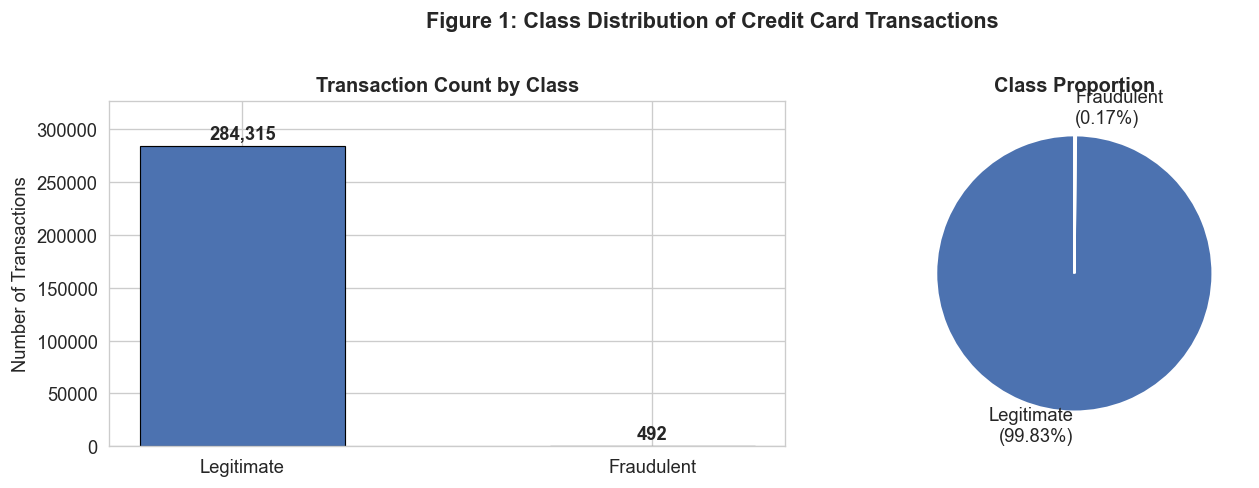

Figure 1 saved.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bar_colors = ['#4C72B0', '#C44E52']

# ── Bar chart ──────────────────────────────────────────────────────────────
bars = axes[0].bar(
    ['Legitimate', 'Fraudulent'],
    [counts[0], counts[1]],
    color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5
)
axes[0].set_title('Transaction Count by Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_ylim(0, counts[0] * 1.15)
for bar, val in zip(bars, [counts[0], counts[1]]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2500,
        f'{val:,}', ha='center', va='bottom', fontweight='bold'
    )

# ── Pie chart ──────────────────────────────────────────────────────────────
axes[1].pie(
    [counts[0], counts[1]],
    labels=['Legitimate\n(99.83%)', 'Fraudulent\n(0.17%)'],
    colors=bar_colors,
    startangle=90,
    explode=(0, 0.1),
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'},
    textprops={'fontsize': 11}
)
axes[1].set_title('Class Proportion', fontsize=12, fontweight='bold')

fig.suptitle('Figure 1: Class Distribution of Credit Card Transactions',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/fig_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

### 3.3 Time and Amount Features

Unlike V1–V28, the `Time` and `Amount` features are in their original (unscaled) units.

- **Time** spans approximately 48 hours of transaction data. Plotting it by class can reveal
  whether fraud clusters at particular times of day.
- **Amount** is the euro value of each transaction. Fraudulent transactions tend to cluster
  at smaller amounts — fraudsters often test cards with small charges before larger ones.

Because these features have different scales than V1–V28, they will require **StandardScaler**
normalization before being fed into distance- or gradient-sensitive models like Logistic Regression.

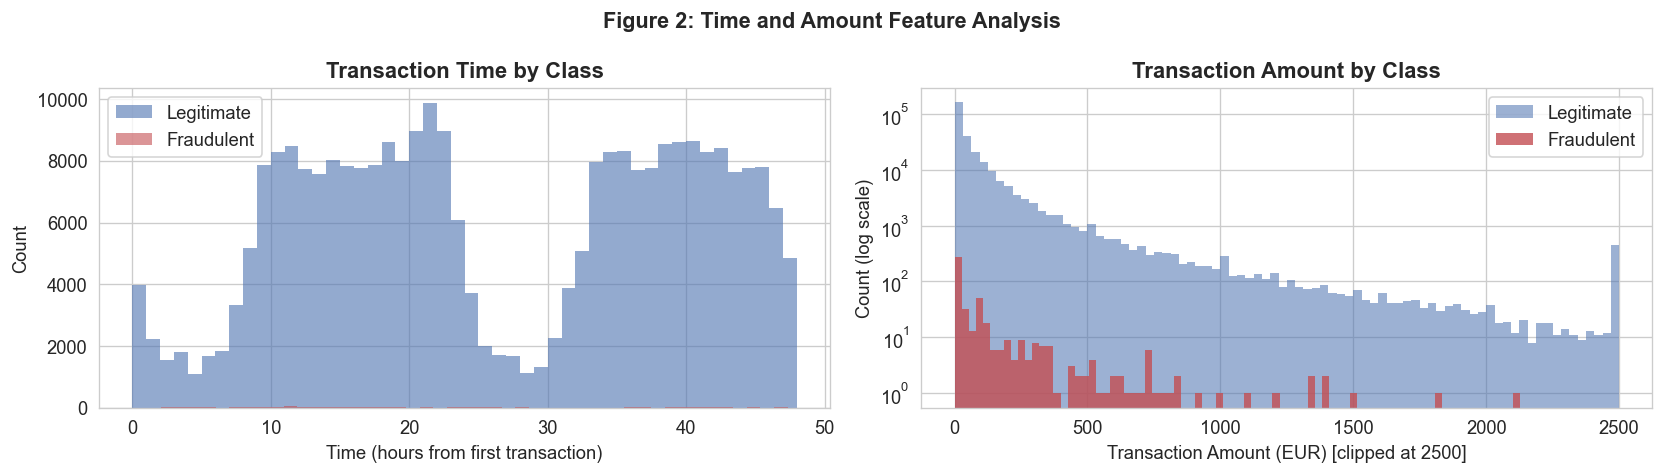

Amount statistics:
  Legitimate — Mean: 88.29 EUR | Median: 22.00 EUR | Max: 25691.16 EUR
  Fraudulent — Mean: 122.21 EUR | Median: 9.25 EUR | Max: 2125.87 EUR
Figure 2 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors = {'Legitimate': '#4C72B0', 'Fraudulent': '#C44E52'}

# ── Time distribution ──────────────────────────────────────────────────────
for cls, label, color in [(0, 'Legitimate', colors['Legitimate']),
                           (1, 'Fraudulent', colors['Fraudulent'])]:
    hours = df[df['Class'] == cls]['Time'] / 3600
    axes[0].hist(hours, bins=48, alpha=0.6, label=label, color=color, edgecolor='none')
axes[0].set_xlabel('Time (hours from first transaction)')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Time by Class', fontweight='bold')
axes[0].legend()

# ── Amount distribution (log scale) ──────────────────────────────────────
df_legit = df[df['Class'] == 0]['Amount']
df_fraud = df[df['Class'] == 1]['Amount']
axes[1].hist(df_legit.clip(upper=2500), bins=80, alpha=0.55,
             color=colors['Legitimate'], label='Legitimate', edgecolor='none')
axes[1].hist(df_fraud.clip(upper=2500), bins=80, alpha=0.8,
             color=colors['Fraudulent'], label='Fraudulent', edgecolor='none')
axes[1].set_xlabel('Transaction Amount (EUR) [clipped at 2500]')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_yscale('log')
axes[1].set_title('Transaction Amount by Class', fontweight='bold')
axes[1].legend()

fig.suptitle('Figure 2: Time and Amount Feature Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_02_time_amount.png', dpi=150, bbox_inches='tight')
plt.show()

print('Amount statistics:')
print(f'  Legitimate — Mean: {df_legit.mean():.2f} EUR | Median: {df_legit.median():.2f} EUR | Max: {df_legit.max():.2f} EUR')
print(f'  Fraudulent — Mean: {df_fraud.mean():.2f} EUR | Median: {df_fraud.median():.2f} EUR | Max: {df_fraud.max():.2f} EUR')
print('Figure 2 saved.')

### 3.4 Feature Correlation Analysis

We compute the absolute Pearson correlation of every feature with the binary target `Class`.
This is a fast linear screening technique that tells us which features have the strongest
*direct* relationship with fraud.

> **Note:** V1–V28 are PCA components and are already uncorrelated with each other by construction,
> so there is no multicollinearity to worry about. High correlation with the target here means the
> PCA component has captured variation that separates fraud from legitimate transactions.

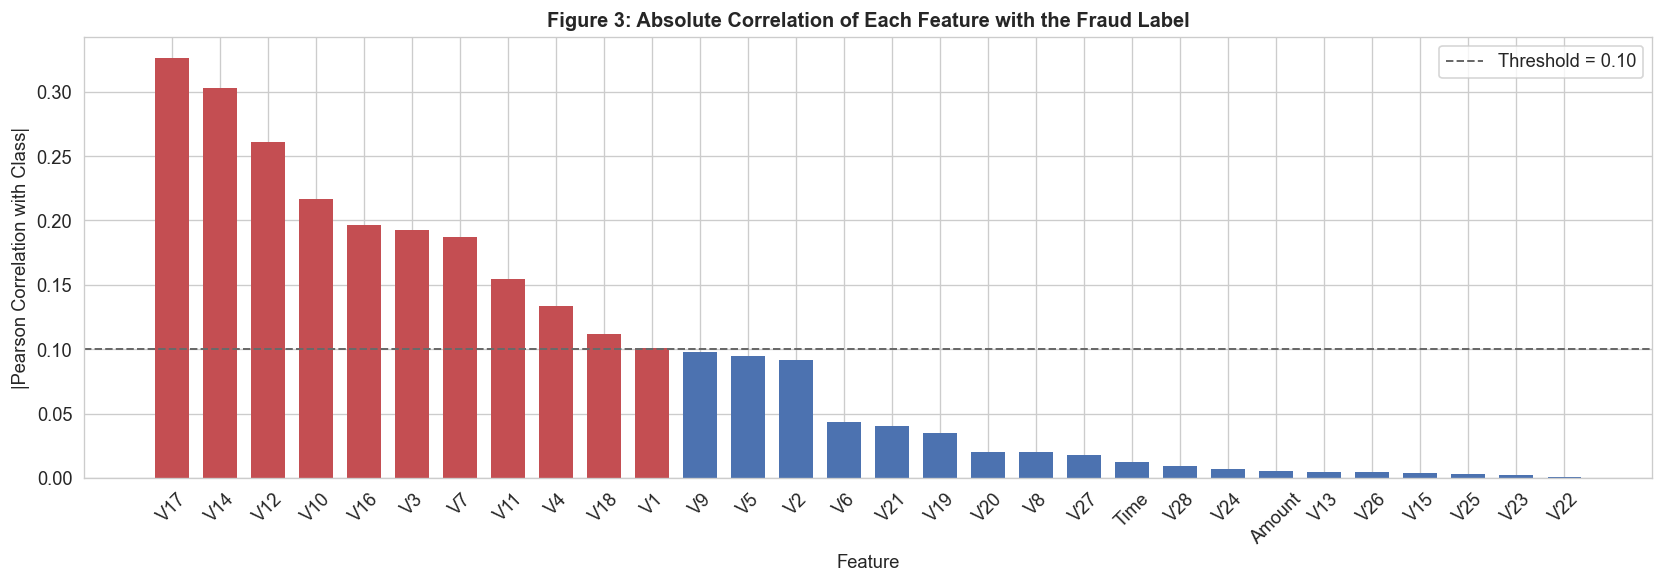

Top 8 features by |correlation|:
  V17        0.3265
  V14        0.3025
  V12        0.2606
  V10        0.2169
  V16        0.1965
  V3         0.1930
  V7         0.1873
  V11        0.1549
Figure 3 saved.


In [7]:
correlations = df.drop('Class', axis=1).corrwith(df['Class']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
bar_cols = ['#C44E52' if v > 0.10 else '#4C72B0' for v in correlations.values]
ax.bar(correlations.index, correlations.values, color=bar_cols, edgecolor='none', width=0.7)
ax.axhline(y=0.10, color='dimgray', linestyle='--', linewidth=1.2, label='Threshold = 0.10')
ax.set_xlabel('Feature')
ax.set_ylabel('|Pearson Correlation with Class|')
ax.set_title('Figure 3: Absolute Correlation of Each Feature with the Fraud Label',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/fig_03_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

TOP_K = 8
top_features = correlations.head(TOP_K).index.tolist()
print(f'Top {TOP_K} features by |correlation|:')
for feat, corr in correlations.head(TOP_K).items():
    print(f'  {feat:<10} {corr:.4f}')
print('Figure 3 saved.')

### 3.5 Top Feature Distributions: Fraud vs. Legitimate

For the top 6 features by correlation, we plot overlapping density histograms for both classes.
Features where the two distributions **barely overlap** will be the most useful discriminators.
Features with almost identical distributions for both classes will contribute little signal.

This informs us about how hard the classification problem is — if every feature overlaps heavily,
we expect lower precision regardless of model choice.

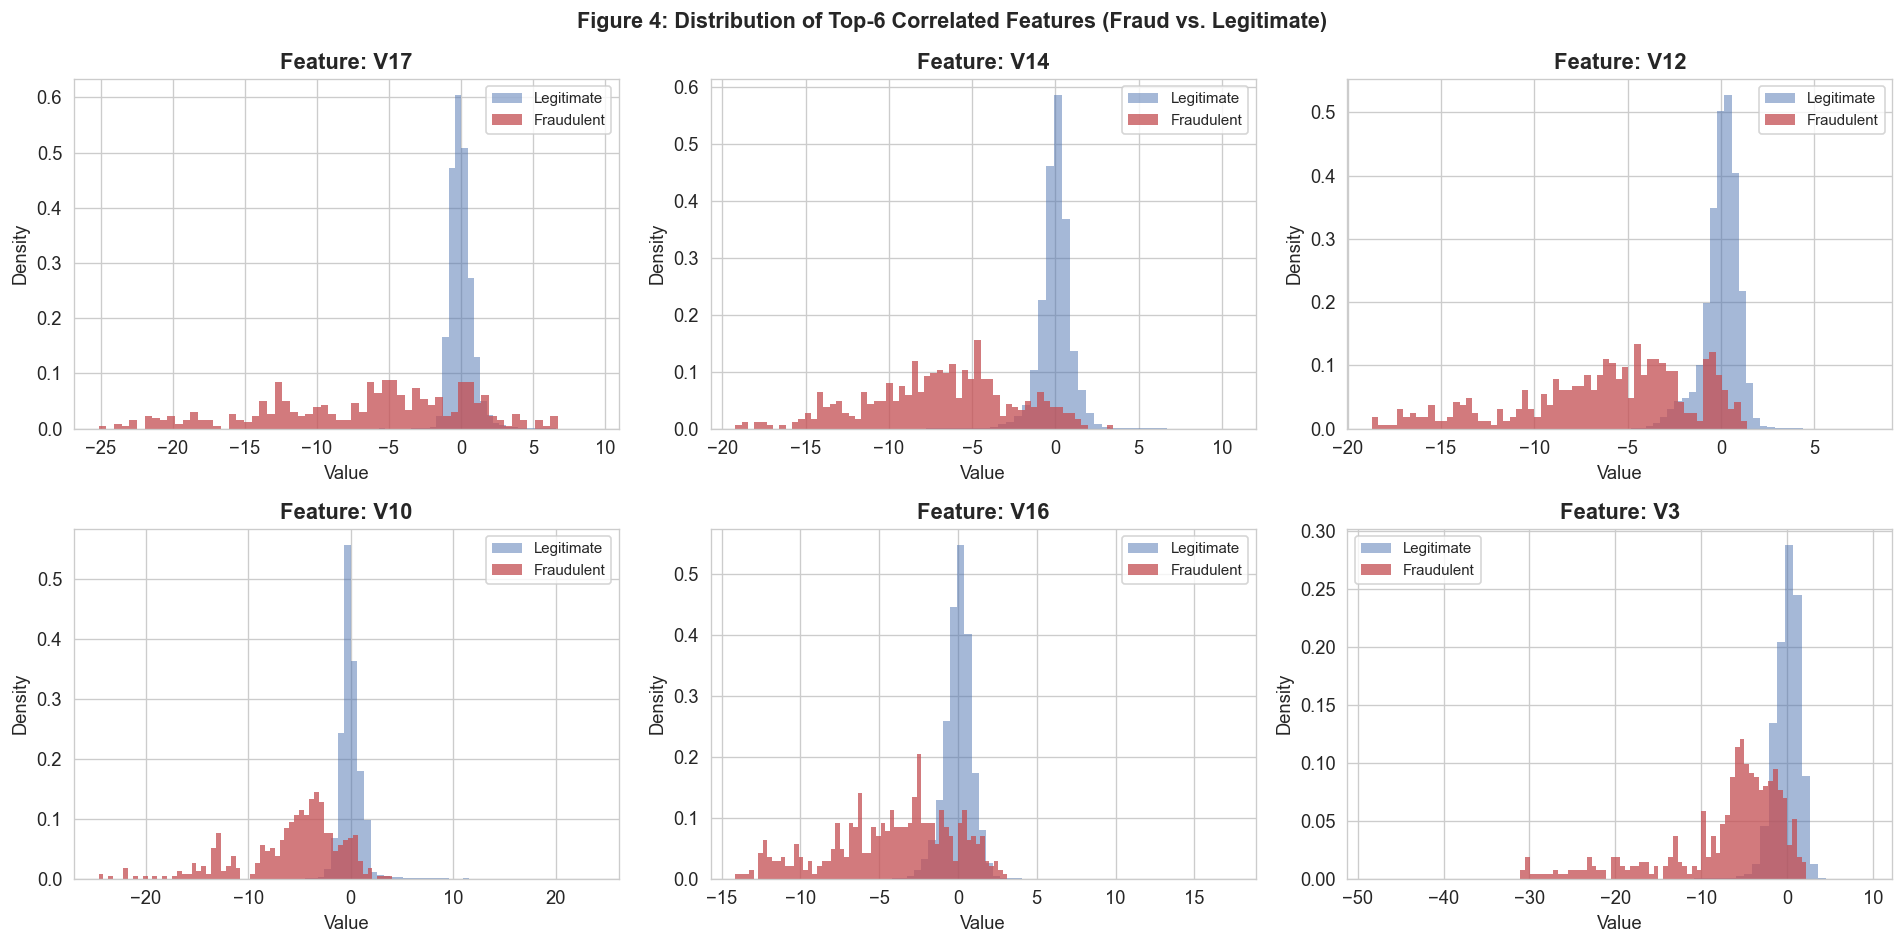

Figure 4 saved.


In [8]:
top_6 = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_6):
    legit_vals = df[df['Class'] == 0][feat]
    fraud_vals = df[df['Class'] == 1][feat]

    axes[i].hist(legit_vals, bins=60, alpha=0.5, color='#4C72B0',
                 label='Legitimate', density=True, edgecolor='none')
    axes[i].hist(fraud_vals, bins=60, alpha=0.75, color='#C44E52',
                 label='Fraudulent', density=True, edgecolor='none')
    axes[i].set_title(f'Feature: {feat}', fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=9)

fig.suptitle('Figure 4: Distribution of Top-6 Correlated Features (Fraud vs. Legitimate)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_04_top_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## 4. Data Preprocessing

A clean, leakage-free preprocessing pipeline is critical for valid model evaluation.
We follow this strict order:

```
1. Split data  →  2. Fit scaler on TRAIN only  →  3. Transform train / val / test
```

Fitting the scaler on the full dataset would **leak** test-set statistics into training,
producing artificially optimistic results that do not reflect real-world performance.
For the midway report, no resampling (SMOTE, under-sampling) is applied — these are
reserved for the final model refinement phase.

### 4.1 Train / Validation / Test Split

We use a **70% / 15% / 15%** stratified split. Stratification ensures the same fraud
prevalence (~0.17%) is preserved in every split — without it, we might accidentally
place very few or zero fraud cases in the validation set.

In [9]:
X = df.drop('Class', axis=1)
y = df['Class']

# Step 1: hold out 15% as test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Step 2: from remaining 85%, hold out ~17.65% as validation (= 15% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_temp
)

print('=' * 55)
print(f'  SPLIT SUMMARY  (total = {len(df):,})')
print('=' * 55)
for split_name, X_s, y_s in [('Train', X_train, y_train),
                               ('Validation', X_val, y_val),
                               ('Test', X_test, y_test)]:
    n_fraud = y_s.sum()
    pct = len(X_s) / len(df) * 100
    print(f'{split_name:<12} : {len(X_s):,} samples ({pct:.1f}%) | '
          f'Fraud: {n_fraud} ({n_fraud/len(y_s)*100:.3f}%)')
print()
print('Stratification verified: fraud prevalence is ~0.17% in all three splits.')

  SPLIT SUMMARY  (total = 284,807)
Train        : 199,356 samples (70.0%) | Fraud: 344 (0.173%)
Validation   : 42,729 samples (15.0%) | Fraud: 74 (0.173%)
Test         : 42,722 samples (15.0%) | Fraud: 74 (0.173%)

Stratification verified: fraud prevalence is ~0.17% in all three splits.


### 4.2 Feature Scaling

We apply `StandardScaler` (zero mean, unit variance) to **only** the `Time` and `Amount` columns.

**Why not scale V1–V28?**  
Features V1–V28 are the output of PCA, which inherently produces zero-mean, decorrelated components.
They are already on a comparable scale. Re-scaling them would be redundant and could slightly
distort their relative magnitudes.

**Critical rule:** The scaler is `fit()` only on `X_train`. We then `transform()` the validation
and test sets using the *training* scaler. This is mandatory to prevent data leakage.

In [10]:
COLS_TO_SCALE = ['Time', 'Amount']

scaler = StandardScaler()

X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

# Fit ONLY on training data, then apply the same transform to val and test
X_train_sc[COLS_TO_SCALE] = scaler.fit_transform(X_train[COLS_TO_SCALE])
X_val_sc[COLS_TO_SCALE]   = scaler.transform(X_val[COLS_TO_SCALE])
X_test_sc[COLS_TO_SCALE]  = scaler.transform(X_test[COLS_TO_SCALE])

print(f'Scaler fitted on training set only.')
print(f'Columns scaled : {COLS_TO_SCALE}')
print()
print('After scaling — training set statistics (should be ~0 mean, ~1 std):')
print(X_train_sc[COLS_TO_SCALE].describe().loc[['mean', 'std']].round(4).to_string())
print()
print('Validation set (will differ slightly — scaler was NOT re-fitted here):')
print(X_val_sc[COLS_TO_SCALE].describe().loc[['mean', 'std']].round(4).to_string())

Scaler fitted on training set only.
Columns scaled : ['Time', 'Amount']

After scaling — training set statistics (should be ~0 mean, ~1 std):
      Time  Amount
mean  -0.0    -0.0
std    1.0     1.0

Validation set (will differ slightly — scaler was NOT re-fitted here):
        Time  Amount
mean -0.0074  0.0010
std   0.9968  1.0354


---
## 5. Baseline Models

We evaluate two models on the **validation set**. The test set is held out and will only
be used for the final evaluation in the complete project.

**Primary metrics** (appropriate for imbalanced data):
- **PR-AUC** (Precision-Recall Area Under Curve): measures how well the model balances
  precision and recall across all thresholds. More informative than ROC-AUC when positives
  are rare.
- **ROC-AUC**: measures the model's ability to rank a random fraud above a random legitimate
  transaction. Useful for comparison but can be overly optimistic on imbalanced data.

**Secondary metrics**: Precision, Recall, F1-score, and Confusion Matrix — all at the
default decision threshold of 0.50 for now.

In [11]:
def evaluate_model(model, X_val, y_val, model_name):
    """
    Evaluates a trained classifier on the validation set.
    Returns: (y_pred, y_prob, roc_auc, pr_auc)
    """
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    roc_auc = roc_auc_score(y_val, y_prob)
    pr_auc  = average_precision_score(y_val, y_prob)
    report  = classification_report(y_val, y_pred,
                                     target_names=['Legitimate', 'Fraudulent'],
                                     digits=4)

    print(f'\n{"=" * 60}')
    print(f'  {model_name} — Validation Set Results')
    print(f'{"=" * 60}')
    print(report)
    print(f'  ROC-AUC  : {roc_auc:.4f}')
    print(f'  PR-AUC   : {pr_auc:.4f}')
    print(f'{"=" * 60}')

    return y_pred, y_prob, roc_auc, pr_auc


def plot_evaluation(y_val, y_pred, y_prob, model_name, fig_prefix):
    """
    Plots confusion matrix, ROC curve, and Precision-Recall curve side by side.
    Saves the figure to reports/figures/.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Confusion Matrix ─────────────────────────────────────────────────────
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Fraudulent']).plot(
        ax=axes[0], colorbar=False, cmap='Blues'
    )
    axes[0].set_title(f'Confusion Matrix', fontweight='bold')

    # ── ROC Curve ─────────────────────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = roc_auc_score(y_val, y_prob)
    axes[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve', fontweight='bold')
    axes[1].legend(loc='lower right', fontsize=9)

    # ── Precision-Recall Curve ────────────────────────────────────────────────
    precision, recall, _ = precision_recall_curve(y_val, y_prob)
    pr_auc = average_precision_score(y_val, y_prob)
    baseline = y_val.mean()
    axes[2].plot(recall, precision, color='#C44E52', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].axhline(y=baseline, color='gray', linestyle='--', lw=1,
                    label=f'Baseline = {baseline:.4f}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Curve', fontweight='bold')
    axes[2].legend(fontsize=9)

    fig.suptitle(f'{model_name} — Evaluation on Validation Set',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_path = f'../reports/figures/{fig_prefix}_evaluation.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved to {save_path}')


print('Helper functions defined: evaluate_model(), plot_evaluation()')

Helper functions defined: evaluate_model(), plot_evaluation()


### 5.1 Logistic Regression

Logistic Regression is our **linear baseline**. It models the log-odds of fraud as a
linear combination of input features:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1+e^{-(\mathbf{w}^\top \mathbf{x}+b)}}$$

**Key choices:**
- **`penalty='l2'`**: L2 (Ridge) regularization. Penalizes large weights by adding
  $\lambda \|\mathbf{w}\|_2^2$ to the loss, which reduces overfitting and handles
  correlated features.
- **`C=1.0`**: Inverse regularization strength. Lower C = stronger regularization.
  We keep the default for the baseline; we will tune it in the final project.
- **`class_weight='balanced'`**: Scikit-learn automatically sets the weight of class $c$
  to $\frac{N}{2 \cdot N_c}$, where $N_c$ is the count of class $c$. This gives the
  rare fraud class ~577× more weight in the loss function, countering the imbalance.

In [12]:
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)
print('Logistic Regression trained successfully.')
print(f'  Penalty        : L2   (C = {lr.C})')
print(f'  Class weight   : balanced')
print(f'  Solver         : lbfgs')
print(f'  Max iterations : {lr.max_iter} (converged = {lr.n_iter_[0] < lr.max_iter})')

Logistic Regression trained successfully.
  Penalty        : L2   (C = 1.0)
  Class weight   : balanced
  Solver         : lbfgs
  Max iterations : 1000 (converged = True)


In [13]:
lr_pred, lr_prob, lr_roc, lr_pr = evaluate_model(lr, X_val_sc, y_val, 'Logistic Regression')


  Logistic Regression — Validation Set Results
              precision    recall  f1-score   support

  Legitimate     0.9999    0.9781    0.9889     42655
  Fraudulent     0.0679    0.9189    0.1265        74

    accuracy                         0.9780     42729
   macro avg     0.5339    0.9485    0.5577     42729
weighted avg     0.9982    0.9780    0.9874     42729

  ROC-AUC  : 0.9860
  PR-AUC   : 0.7520


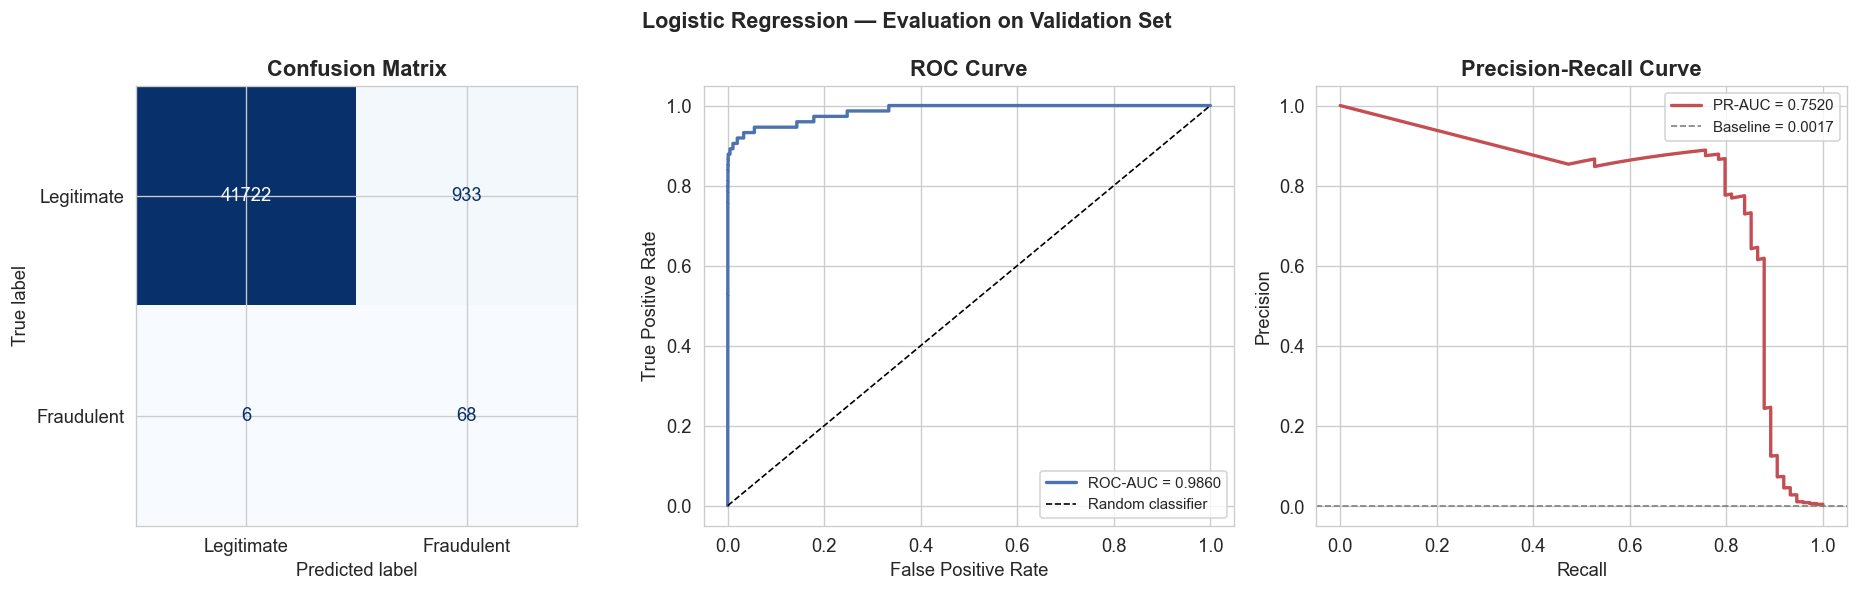

Figure saved to ../reports/figures/fig_05_lr_evaluation.png


In [14]:
plot_evaluation(y_val, lr_pred, lr_prob, 'Logistic Regression', 'fig_05_lr')

**Interpreting Logistic Regression results:**

- High **Recall** for fraud is expected with `class_weight='balanced'` — the model is
  incentivized to catch most fraud cases at the cost of more false positives.
- Low **Precision** for fraud at threshold 0.5 is also expected: because fraud is so rare,
  even a small false positive rate produces many false alarms.
- **PR-AUC** is the key metric here — it captures this precision-recall trade-off across
  all thresholds. Threshold tuning (to find the optimal operating point) is planned for
  the final project.

### 5.2 Random Forest

Random Forest is an **ensemble of decision trees**, each trained on a bootstrap sample
of the data with a random feature subset at each split. Predictions are made by
majority vote across all trees.

**Why Random Forest after Logistic Regression?**  
Logistic Regression can only learn a **linear** decision boundary. Fraud patterns often
involve nonlinear feature interactions (e.g., large `Amount` combined with a specific
range of `V4`). Random Forest captures these nonlinear relationships automatically.

**Key choices:**
- **`n_estimators=100`**: 100 trees — a standard starting point that balances accuracy
  and training time.
- **`class_weight='balanced'`**: Same balancing approach as Logistic Regression.
- **`n_jobs=-1`**: Uses all available CPU cores to speed up training.

In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)
print('Random Forest trained successfully.')
print(f'  Trees          : {rf.n_estimators}')
print(f'  Class weight   : balanced')
print(f'  Features used  : {rf.n_features_in_}')

Random Forest trained successfully.
  Trees          : 100
  Class weight   : balanced
  Features used  : 30


In [16]:
rf_pred, rf_prob, rf_roc, rf_pr = evaluate_model(rf, X_val_sc, y_val, 'Random Forest')


  Random Forest — Validation Set Results
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9999    0.9998     42655
  Fraudulent     0.9365    0.7973    0.8613        74

    accuracy                         0.9996     42729
   macro avg     0.9681    0.8986    0.9305     42729
weighted avg     0.9995    0.9996    0.9995     42729

  ROC-AUC  : 0.9514
  PR-AUC   : 0.8637


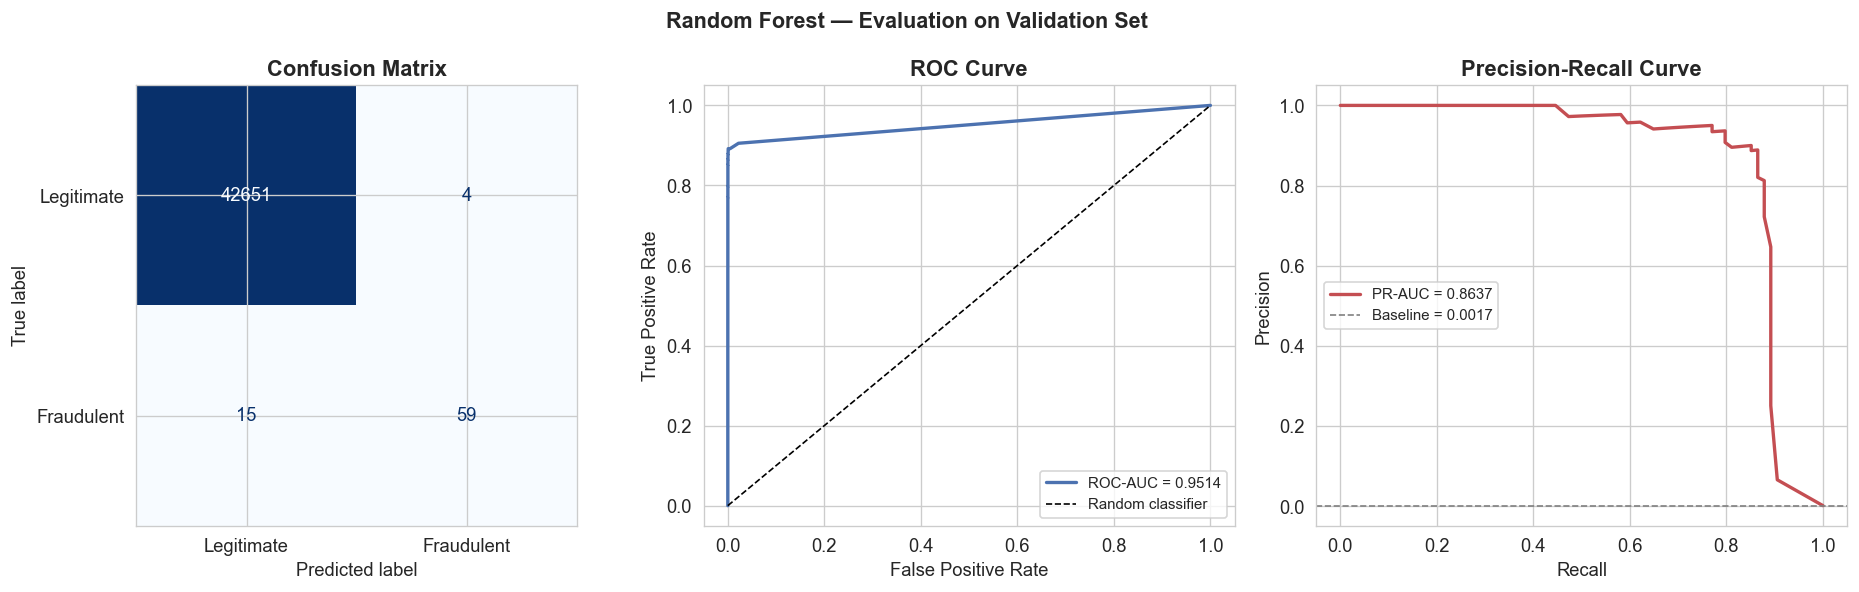

Figure saved to ../reports/figures/fig_06_rf_evaluation.png


In [17]:
plot_evaluation(y_val, rf_pred, rf_prob, 'Random Forest', 'fig_06_rf')

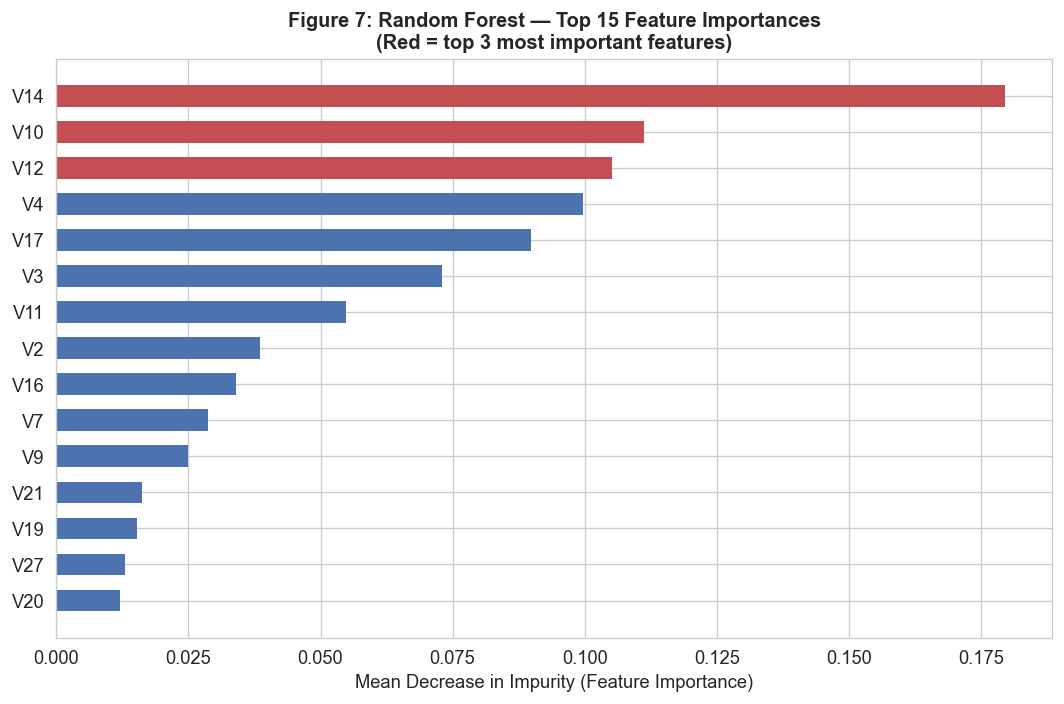

Top 5 features by Random Forest importance:
V14    0.1796
V10    0.1112
V12    0.1052
V4     0.0996
V17    0.0899
Figure 7 saved.


In [18]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#C44E52' if feat in top15.tail(3).index else '#4C72B0'
              for feat in top15.index]
ax.barh(top15.index, top15.values, color=bar_colors, edgecolor='none', height=0.6)
ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)')
ax.set_title('Figure 7: Random Forest — Top 15 Feature Importances\n'
             '(Red = top 3 most important features)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('../reports/figures/fig_07_feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features by Random Forest importance:')
print(importances.sort_values(ascending=False).head(5).round(4).to_string())
print('Figure 7 saved.')

**Interpreting Random Forest feature importances:**

Feature importance in a Random Forest is measured by **Mean Decrease in Impurity (MDI)**:
how much each feature reduces Gini impurity (a measure of class mixing) across all tree
splits, averaged over all 100 trees. A higher importance means the feature is used more
often to split nodes and provides cleaner separations.

Comparing these importances to the correlation analysis in Section 3.4 shows whether
the *linear* correlation screening and the *nonlinear* tree-based importance agree on
which features are most discriminative.

---
## 6. Baseline Model Comparison

We summarize Logistic Regression and Random Forest on the validation set at the default
decision threshold of 0.50. These establish the baseline before imbalance handling,
threshold tuning, and the third model (GBT) are introduced in Sections 7–9.

In [19]:
def get_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {
        'ROC-AUC'        : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'         : round(average_precision_score(y_true, y_prob), 4),
        'Fraud Recall'   : round(report['1']['recall'], 4),
        'Fraud Precision': round(report['1']['precision'], 4),
        'Fraud F1'       : round(report['1']['f1-score'], 4),
    }

results = pd.DataFrame({
    'Logistic Regression': get_metrics(y_val, lr_pred, lr_prob),
    'Random Forest'      : get_metrics(y_val, rf_pred, rf_prob),
}).T

print('=' * 65)
print('  MODEL COMPARISON SUMMARY (Validation Set, threshold = 0.50)')
print('=' * 65)
print(results.to_string())
print()

results.to_csv('../reports/results_summary.csv')
print('Results saved to ../reports/results_summary.csv')

  MODEL COMPARISON SUMMARY (Validation Set, threshold = 0.50)
                     ROC-AUC  PR-AUC  Fraud Recall  Fraud Precision  Fraud F1
Logistic Regression   0.9860  0.7520        0.9189           0.0679    0.1265
Random Forest         0.9514  0.8637        0.7973           0.9365    0.8613

Results saved to ../reports/results_summary.csv


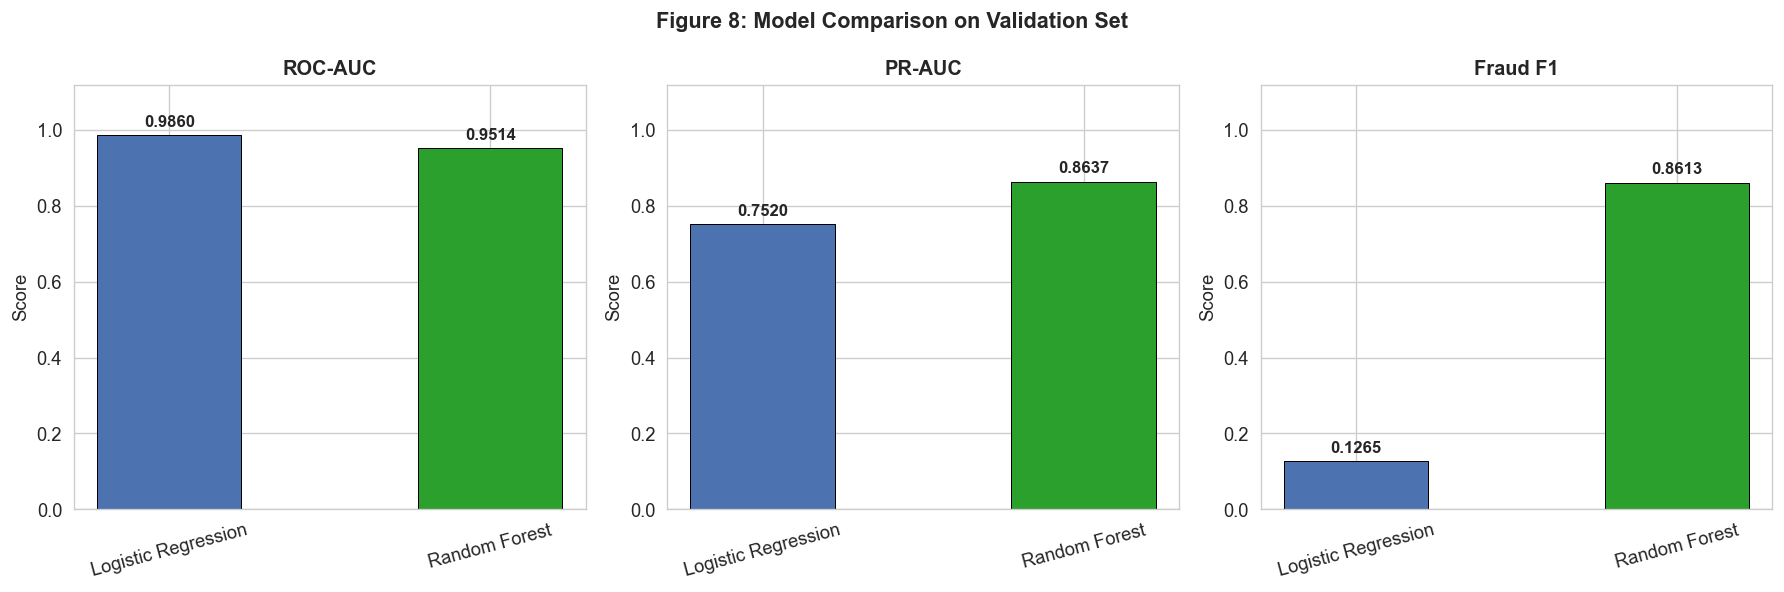

Figure 8 saved.


In [20]:
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'Fraud F1']
model_colors = ['#4C72B0', '#2CA02C']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(metrics_to_plot):
    vals = results[metric].values
    bars = axes[idx].bar(
        results.index, vals,
        color=model_colors, edgecolor='black', linewidth=0.6, width=0.45
    )
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    axes[idx].set_ylim(0, 1.12)
    axes[idx].set_ylabel('Score')
    axes[idx].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10
        )

fig.suptitle('Figure 8: Model Comparison on Validation Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_08_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

---
## 7. Imbalance Handling Experiments

The training set has a 578:1 class ratio. Beyond `class_weight='balanced'` (already used
in Section 5), two resampling strategies are evaluated here:

- **SMOTE** (Synthetic Minority Oversampling Technique): generates synthetic fraud samples
  by interpolating between existing fraud samples in feature space, bringing the training
  set to a 1:1 ratio.
- **Random Under-Sampling**: randomly discards majority-class (legitimate) samples until the
  ratio is 1:1.

**Key rule:** resampling is applied **only to the training set**. The validation set is never
modified — it must reflect the true class distribution to give meaningful metrics.

We use Logistic Regression (fast) as the evaluation vehicle for resampling strategies,
then apply the best strategy to GBT in Section 8.

### 7.1 SMOTE — Synthetic Minority Oversampling

In [21]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train)

print('SMOTE applied to training set only.')
print(f'  Before — Legitimate: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}')
print(f'  After  — Legitimate: {(y_train_smote==0).sum():,}  |  Fraud: {(y_train_smote==1).sum():,}')
print(f'  New training set size: {len(y_train_smote):,}')

lr_smote = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
)
lr_smote.fit(X_train_smote, y_train_smote)

lr_smote_prob = lr_smote.predict_proba(X_val_sc)[:, 1]
lr_smote_pred = (lr_smote_prob >= 0.5).astype(int)

roc_smote = roc_auc_score(y_val, lr_smote_prob)
pr_smote  = average_precision_score(y_val, lr_smote_prob)
f1_smote  = f1_score(y_val, lr_smote_pred)

print(f'\nLR + SMOTE — Validation results (threshold=0.5):')
print(f'  ROC-AUC : {roc_smote:.4f}')
print(f'  PR-AUC  : {pr_smote:.4f}')
print(f'  Fraud F1: {f1_smote:.4f}')
print(f'  Recall  : {recall_score(y_val, lr_smote_pred):.4f}')
print(f'  Precision: {precision_score(y_val, lr_smote_pred):.4f}')

SMOTE applied to training set only.
  Before — Legitimate: 199,012  |  Fraud: 344
  After  — Legitimate: 199,012  |  Fraud: 199,012
  New training set size: 398,024



LR + SMOTE — Validation results (threshold=0.5):
  ROC-AUC : 0.9814
  PR-AUC  : 0.7599
  Fraud F1: 0.1209
  Recall  : 0.9324
  Precision: 0.0647


### 7.2 Random Under-Sampling

In [22]:
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_rus, y_train_rus = rus.fit_resample(X_train_sc, y_train)

print('Random Under-Sampling applied to training set only.')
print(f'  Before — Legitimate: {(y_train==0).sum():,}  |  Fraud: {(y_train==1).sum():,}')
print(f'  After  — Legitimate: {(y_train_rus==0).sum():,}  |  Fraud: {(y_train_rus==1).sum():,}')
print(f'  New training set size: {len(y_train_rus):,}')

lr_rus = LogisticRegression(
    penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
)
lr_rus.fit(X_train_rus, y_train_rus)

lr_rus_prob = lr_rus.predict_proba(X_val_sc)[:, 1]
lr_rus_pred = (lr_rus_prob >= 0.5).astype(int)

roc_rus = roc_auc_score(y_val, lr_rus_prob)
pr_rus  = average_precision_score(y_val, lr_rus_prob)
f1_rus  = f1_score(y_val, lr_rus_pred)

print(f'\nLR + Under-Sampling — Validation results (threshold=0.5):')
print(f'  ROC-AUC : {roc_rus:.4f}')
print(f'  PR-AUC  : {pr_rus:.4f}')
print(f'  Fraud F1: {f1_rus:.4f}')
print(f'  Recall  : {recall_score(y_val, lr_rus_pred):.4f}')
print(f'  Precision: {precision_score(y_val, lr_rus_pred):.4f}')

Random Under-Sampling applied to training set only.
  Before — Legitimate: 199,012  |  Fraud: 344
  After  — Legitimate: 344  |  Fraud: 344
  New training set size: 688

LR + Under-Sampling — Validation results (threshold=0.5):
  ROC-AUC : 0.9778
  PR-AUC  : 0.6986
  Fraud F1: 0.0865
  Recall  : 0.9324
  Precision: 0.0454


### 7.3 Resampling Strategy Comparison

We compare all three imbalance-handling strategies (class weighting, SMOTE,
under-sampling) on the same Logistic Regression model and validation set.

  RESAMPLING STRATEGY COMPARISON (LR, validation set, threshold=0.5)
                     ROC-AUC  PR-AUC  Fraud F1  Recall  Precision
LR + class_weight     0.9860  0.7520    0.1265  0.9189     0.0679
LR + SMOTE            0.9814  0.7599    0.1209  0.9324     0.0647
LR + Under-Sampling   0.9778  0.6986    0.0865  0.9324     0.0454


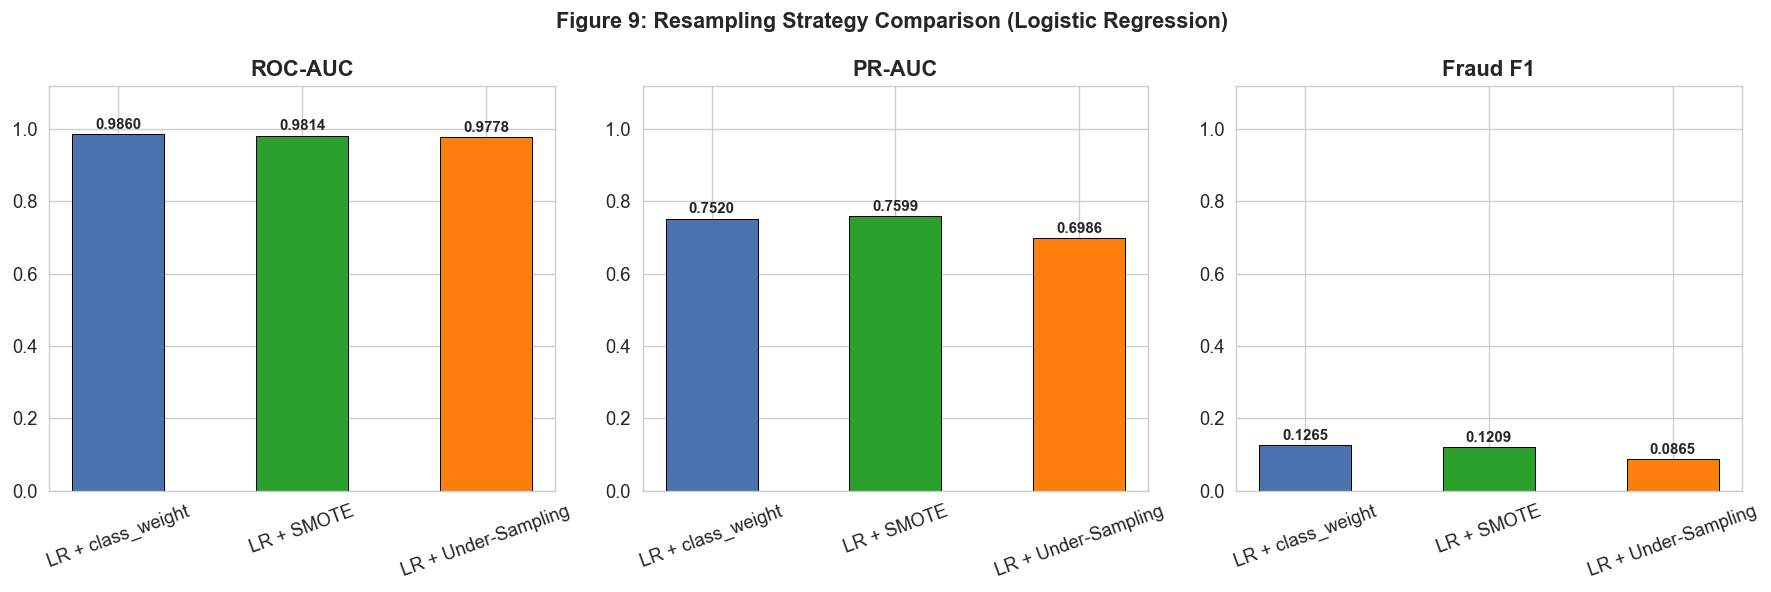

Figure 9 saved.

Best resampling strategy by PR-AUC: LR + SMOTE


In [23]:
resample_results = pd.DataFrame({
    'LR + class_weight': {
        'ROC-AUC': round(lr_roc, 4),
        'PR-AUC' : round(lr_pr,  4),
        'Fraud F1': round(f1_score(y_val, lr_pred), 4),
        'Recall' : round(recall_score(y_val, lr_pred), 4),
        'Precision': round(precision_score(y_val, lr_pred), 4),
    },
    'LR + SMOTE': {
        'ROC-AUC': round(roc_smote, 4),
        'PR-AUC' : round(pr_smote,  4),
        'Fraud F1': round(f1_smote, 4),
        'Recall' : round(recall_score(y_val, lr_smote_pred), 4),
        'Precision': round(precision_score(y_val, lr_smote_pred), 4),
    },
    'LR + Under-Sampling': {
        'ROC-AUC': round(roc_rus, 4),
        'PR-AUC' : round(pr_rus,  4),
        'Fraud F1': round(f1_rus, 4),
        'Recall' : round(recall_score(y_val, lr_rus_pred), 4),
        'Precision': round(precision_score(y_val, lr_rus_pred), 4),
    },
}).T

print('=' * 70)
print('  RESAMPLING STRATEGY COMPARISON (LR, validation set, threshold=0.5)')
print('=' * 70)
print(resample_results.to_string())

# ── Bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['ROC-AUC', 'PR-AUC', 'Fraud F1']
colors  = ['#4C72B0', '#2CA02C', '#FF7F0E']

for i, metric in enumerate(metrics):
    vals = resample_results[metric].values
    bars = axes[i].bar(resample_results.index, vals, color=colors, edgecolor='black',
                       linewidth=0.6, width=0.5)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylim(0, 1.12)
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
                     f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Figure 9: Resampling Strategy Comparison (Logistic Regression)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_09_resampling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

# Identify best strategy by PR-AUC
best_strat = resample_results['PR-AUC'].idxmax()
print(f'\nBest resampling strategy by PR-AUC: {best_strat}')

---
## 8. Gradient Boosted Trees (Third Model)

`HistGradientBoostingClassifier` (sklearn's histogram-based GBT) is our third model.
It builds an additive ensemble of shallow trees, where each tree corrects the residual
errors of the previous ones. Key advantages for this dataset:

- Handles class imbalance natively via `class_weight='balanced'`
- Fast training via histogram binning (O(n) per split vs O(n log n) for exact GBT)
- Strong performance on tabular data without feature engineering
- Built-in support for missing values (irrelevant here but good practice)

We train two variants:
1. **GBT + class_weight='balanced'** (no resampling)
2. **GBT + SMOTE** (best resampling strategy from Section 7, applied to training only)

GBT (class_weight=balanced) trained.

  GBT (balanced weights) — Validation Set Results
              precision    recall  f1-score   support

  Legitimate     0.9998    0.9965    0.9981     42655
  Fraudulent     0.3056    0.8919    0.4552        74

    accuracy                         0.9963     42729
   macro avg     0.6527    0.9442    0.7267     42729
weighted avg     0.9986    0.9963    0.9972     42729

  ROC-AUC  : 0.9822
  PR-AUC   : 0.7840


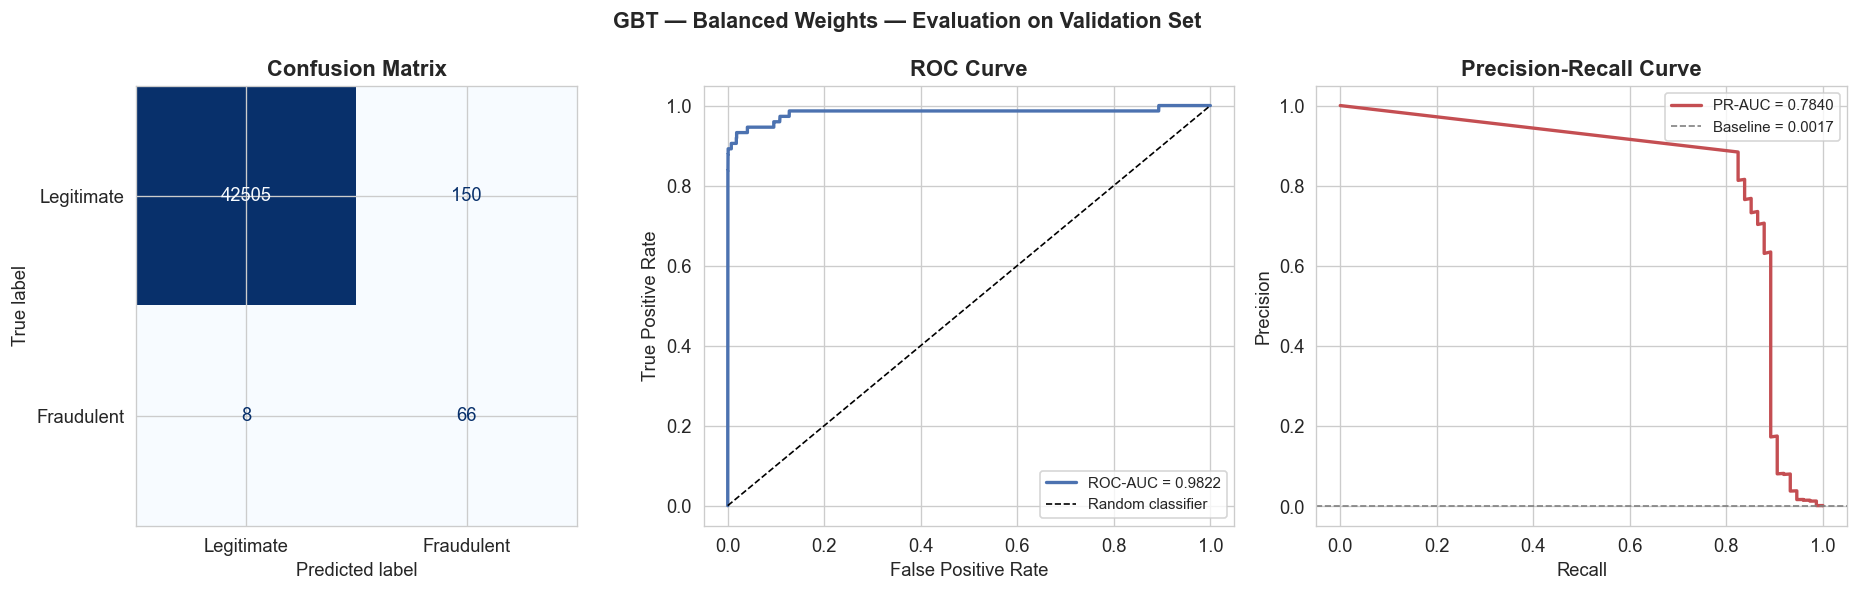

Figure saved to ../reports/figures/fig_10_gbt_balanced_evaluation.png


In [24]:
# ── GBT variant 1: balanced class_weight ─────────────────────────────────
gbt = HistGradientBoostingClassifier(
    max_iter=200,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)
gbt.fit(X_train_sc, y_train)
print('GBT (class_weight=balanced) trained.')

gbt_pred, gbt_prob, gbt_roc, gbt_pr = evaluate_model(gbt, X_val_sc, y_val, 'GBT (balanced weights)')
plot_evaluation(y_val, gbt_pred, gbt_prob, 'GBT — Balanced Weights', 'fig_10_gbt_balanced')

In [25]:
# ── GBT variant 2: SMOTE-resampled training data ─────────────────────────
gbt_smote = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=RANDOM_STATE,
)
gbt_smote.fit(X_train_smote, y_train_smote)
print('GBT (SMOTE) trained.')

gbt_smote_pred, gbt_smote_prob, gbt_smote_roc, gbt_smote_pr = evaluate_model(
    gbt_smote, X_val_sc, y_val, 'GBT (SMOTE)'
)

# ── Full 3-model comparison table ─────────────────────────────────────────
def row_metrics(y_true, y_pred, y_prob):
    return {
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'   : round(average_precision_score(y_true, y_prob), 4),
        'Recall'   : round(recall_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'F1'       : round(f1_score(y_true, y_pred), 4),
    }

all_results = pd.DataFrame({
    'LR (balanced)'   : row_metrics(y_val, lr_pred,       lr_prob),
    'RF (balanced)'   : row_metrics(y_val, rf_pred,       rf_prob),
    'GBT (balanced)'  : row_metrics(y_val, gbt_pred,      gbt_prob),
    'GBT (SMOTE)'     : row_metrics(y_val, gbt_smote_pred, gbt_smote_prob),
}).T

print('=' * 65)
print('  ALL MODELS — Validation Set (threshold = 0.50)')
print('=' * 65)
print(all_results.to_string())

GBT (SMOTE) trained.

  GBT (SMOTE) — Validation Set Results
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9995    0.9996     42655
  Fraudulent     0.7470    0.8378    0.7898        74

    accuracy                         0.9992     42729
   macro avg     0.8734    0.9187    0.8947     42729
weighted avg     0.9993    0.9992    0.9992     42729

  ROC-AUC  : 0.9729
  PR-AUC   : 0.8533


  ALL MODELS — Validation Set (threshold = 0.50)
                ROC-AUC  PR-AUC  Recall  Precision      F1
LR (balanced)    0.9860  0.7520  0.9189     0.0679  0.1265
RF (balanced)    0.9514  0.8637  0.7973     0.9365  0.8613
GBT (balanced)   0.9822  0.7840  0.8919     0.3056  0.4552
GBT (SMOTE)      0.9729  0.8533  0.8378     0.7470  0.7898


---
## 9. Threshold Tuning

At the default threshold of 0.50, high-recall models produce many false positives
and high-precision models miss frauds. The optimal threshold depends on the
application's cost tolerance.

We sweep thresholds from 0.01 to 0.99 for each model and compute:
- **F1-score** — harmonic mean of Precision and Recall
- **Precision** and **Recall** individually

The **F1-maximizing threshold** is selected for each model and used as the
primary operating point going forward. Cost-sensitive threshold selection is in Section 10.

In [26]:
THRESHOLDS = np.linspace(0.01, 0.99, 200)

def threshold_sweep(y_true, y_prob, thresholds):
    records = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        records.append({
            'threshold': t,
            'f1'       : f1_score(y_true, y_pred_t, zero_division=0),
            'precision': precision_score(y_true, y_pred_t, zero_division=0),
            'recall'   : recall_score(y_true, y_pred_t, zero_division=0),
        })
    return pd.DataFrame(records)

models_for_tuning = {
    'LR (balanced)' : lr_prob,
    'RF (balanced)' : rf_prob,
    'GBT (balanced)': gbt_prob,
    'GBT (SMOTE)'   : gbt_smote_prob,
}

sweep_data   = {}
best_thresh  = {}

for name, probs in models_for_tuning.items():
    df_sweep = threshold_sweep(y_val, probs, THRESHOLDS)
    sweep_data[name] = df_sweep
    best_idx = df_sweep['f1'].idxmax()
    best_thresh[name] = df_sweep.loc[best_idx, 'threshold']
    print(f'{name:<20} | Best threshold: {best_thresh[name]:.3f} | '
          f'F1: {df_sweep.loc[best_idx,"f1"]:.4f} | '
          f'P: {df_sweep.loc[best_idx,"precision"]:.4f} | '
          f'R: {df_sweep.loc[best_idx,"recall"]:.4f}')

print('\nBest F1-maximizing thresholds saved.')

LR (balanced)        | Best threshold: 0.990 | F1: 0.7273 | P: 0.6275 | R: 0.8649


RF (balanced)        | Best threshold: 0.192 | F1: 0.8767 | P: 0.8889 | R: 0.8649


GBT (balanced)       | Best threshold: 0.951 | F1: 0.8531 | P: 0.8841 | R: 0.8243


GBT (SMOTE)          | Best threshold: 0.960 | F1: 0.8794 | P: 0.9254 | R: 0.8378

Best F1-maximizing thresholds saved.


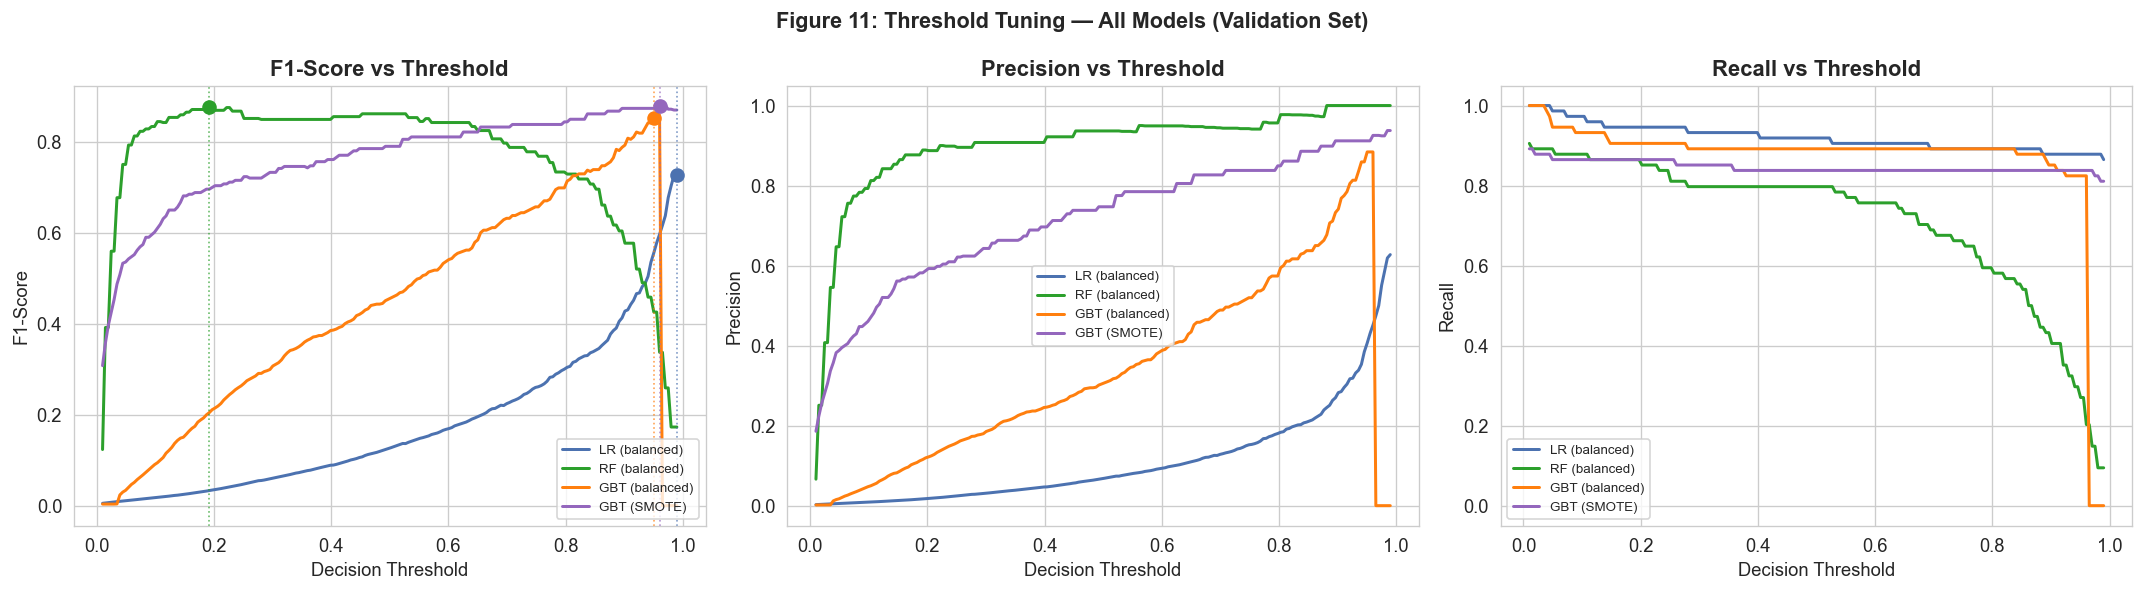

Figure 11 saved.


In [27]:
colors_map = {
    'LR (balanced)' : '#4C72B0',
    'RF (balanced)' : '#2CA02C',
    'GBT (balanced)': '#FF7F0E',
    'GBT (SMOTE)'   : '#9467BD',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_labels = [('f1', 'F1-Score'), ('precision', 'Precision'), ('recall', 'Recall')]

for ax, (col, label) in zip(axes, metrics_labels):
    for name, df_sw in sweep_data.items():
        ax.plot(df_sw['threshold'], df_sw[col], label=name, color=colors_map[name], lw=1.8)
    # Mark best F1 threshold for each model
    if col == 'f1':
        for name, df_sw in sweep_data.items():
            best_t = best_thresh[name]
            best_f1 = df_sw.loc[df_sw['threshold'].sub(best_t).abs().idxmin(), 'f1']
            ax.axvline(x=best_t, color=colors_map[name], linestyle=':', lw=1, alpha=0.7)
            ax.scatter([best_t], [best_f1], color=colors_map[name], s=60, zorder=5)
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel(label)
    ax.set_title(f'{label} vs Threshold', fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Figure 11: Threshold Tuning — All Models (Validation Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_11_threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved.')

---
## 10. Cost-Sensitive Evaluation

In production, the cost of **missing a fraud** (False Negative) and the cost of
**investigating a legitimate transaction** (False Positive) are very different.

We model the expected business cost per threshold as:

$$\text{Cost}(t) = \text{FN}(t) \times C_{\text{FN}} + \text{FP}(t) \times C_{\text{FP}}$$

where:
- $C_{\text{FN}} = 500$ EUR — average loss from an undetected fraud transaction
- $C_{\text{FP}} = 10$ EUR — cost of manually reviewing a flagged legitimate transaction

These values are representative of a mid-sized European bank. By sweeping $t$, we find
the **cost-minimizing threshold** for each model, which will typically be lower than the
F1-maximizing threshold (favouring recall over precision).

In [28]:
C_FN = 500   # EUR — cost of missing one fraud
C_FP = 10    # EUR — cost of investigating one false alarm

def cost_sweep(y_true, y_prob, thresholds, c_fn=C_FN, c_fp=C_FP):
    records = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred_t, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        total_cost = fn * c_fn + fp * c_fp
        records.append({'threshold': t, 'total_cost': total_cost, 'FN': fn, 'FP': fp})
    return pd.DataFrame(records)

cost_data      = {}
best_cost_thresh = {}

print(f'Cost matrix: FN = {C_FN} EUR | FP = {C_FP} EUR\n')

for name, probs in models_for_tuning.items():
    df_cost = cost_sweep(y_val, probs, THRESHOLDS)
    cost_data[name] = df_cost
    best_idx = df_cost['total_cost'].idxmin()
    best_cost_thresh[name] = df_cost.loc[best_idx, 'threshold']
    min_cost = df_cost.loc[best_idx, 'total_cost']
    fn_at_best = df_cost.loc[best_idx, 'FN']
    fp_at_best = df_cost.loc[best_idx, 'FP']
    print(f'{name:<20} | Cost-opt threshold: {best_cost_thresh[name]:.3f} | '
          f'Min cost: {min_cost:.0f} EUR | FN: {fn_at_best} | FP: {fp_at_best}')

print('\nCost-minimizing thresholds saved.')

Cost matrix: FN = 500 EUR | FP = 10 EUR



LR (balanced)        | Cost-opt threshold: 0.985 | Min cost: 4900 EUR | FN: 9 | FP: 40


RF (balanced)        | Cost-opt threshold: 0.044 | Min cost: 4360 EUR | FN: 8 | FP: 36


GBT (balanced)       | Cost-opt threshold: 0.837 | Min cost: 4390 EUR | FN: 8 | FP: 39


GBT (SMOTE)          | Cost-opt threshold: 0.251 | Min cost: 5390 EUR | FN: 10 | FP: 39

Cost-minimizing thresholds saved.


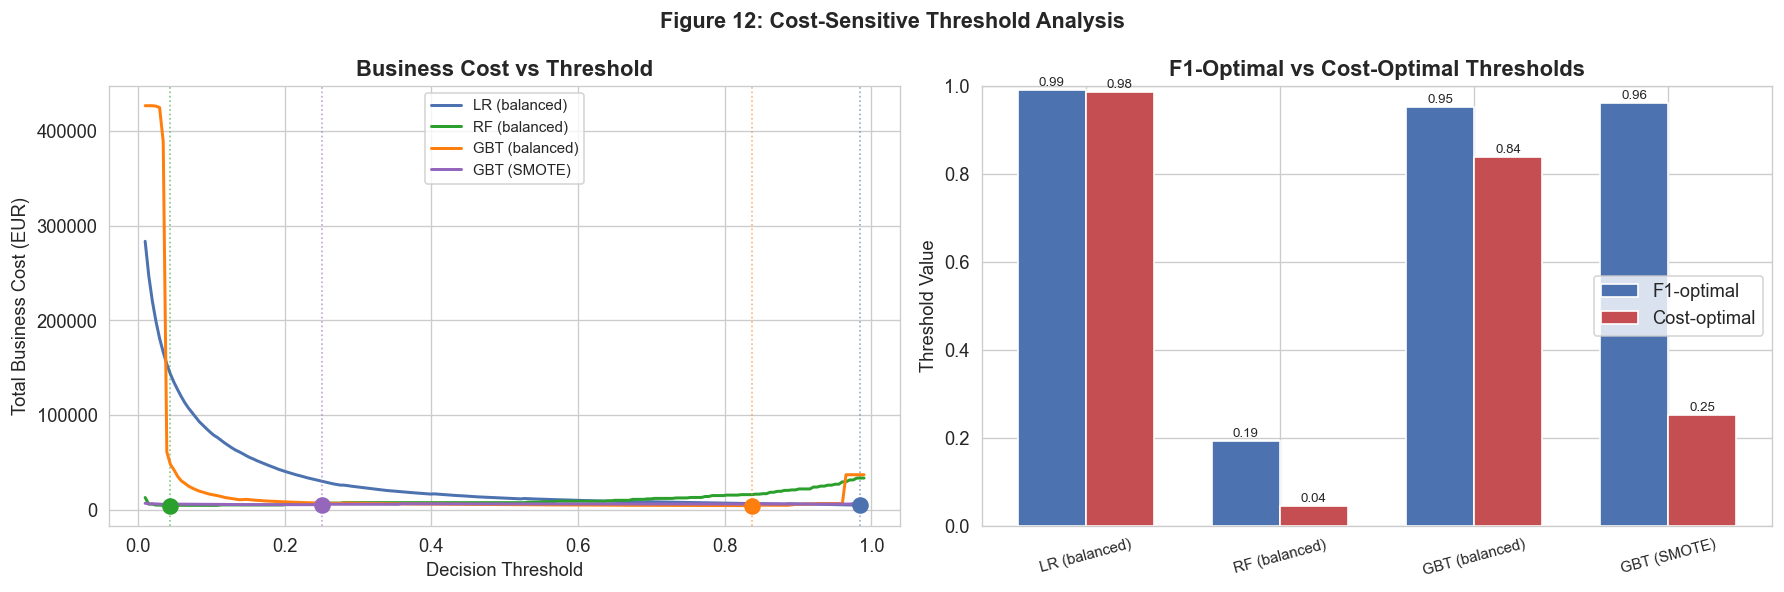

Threshold comparison table:
                F1-optimal threshold  Cost-optimal threshold
LR (balanced)                  0.990                   0.985
RF (balanced)                  0.192                   0.044
GBT (balanced)                 0.951                   0.837
GBT (SMOTE)                    0.960                   0.251

Figure 12 saved.

Interpretation: Cost-optimal thresholds are lower than F1-optimal,
reflecting the high FN penalty (€500 missed fraud >> €10 false alarm).


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Cost vs threshold ────────────────────────────────────────────────────
for name, df_cost in cost_data.items():
    axes[0].plot(df_cost['threshold'], df_cost['total_cost'],
                 label=name, color=colors_map[name], lw=1.8)
    opt_t = best_cost_thresh[name]
    min_c = df_cost.loc[df_cost['threshold'].sub(opt_t).abs().idxmin(), 'total_cost']
    axes[0].scatter([opt_t], [min_c], color=colors_map[name], s=80, zorder=5)
    axes[0].axvline(x=opt_t, color=colors_map[name], linestyle=':', lw=1, alpha=0.6)

axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Business Cost (EUR)')
axes[0].set_title('Business Cost vs Threshold', fontweight='bold')
axes[0].legend(fontsize=9)

# ── F1-opt vs cost-opt threshold comparison ───────────────────────────────
thresh_compare = pd.DataFrame({
    name: {
        'F1-optimal threshold': round(best_thresh[name], 3),
        'Cost-optimal threshold': round(best_cost_thresh[name], 3),
    }
    for name in models_for_tuning
}).T

x = np.arange(len(thresh_compare))
w = 0.35
bars1 = axes[1].bar(x - w/2, thresh_compare['F1-optimal threshold'],  w, label='F1-optimal',   color='#4C72B0')
bars2 = axes[1].bar(x + w/2, thresh_compare['Cost-optimal threshold'], w, label='Cost-optimal', color='#C44E52')
axes[1].set_xticks(x)
axes[1].set_xticklabels(thresh_compare.index, rotation=15, fontsize=9)
axes[1].set_ylabel('Threshold Value')
axes[1].set_title('F1-Optimal vs Cost-Optimal Thresholds', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1)
for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.2f}', ha='center', fontsize=8)

fig.suptitle('Figure 12: Cost-Sensitive Threshold Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_12_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Threshold comparison table:')
print(thresh_compare.to_string())
print('\nFigure 12 saved.')
print('\nInterpretation: Cost-optimal thresholds are lower than F1-optimal,')
print('reflecting the high FN penalty (€500 missed fraud >> €10 false alarm).')

---
## 11. Final Test Set Evaluation

We now select the **best model + threshold** pair from the validation set analysis
and evaluate it on the **held-out test set exactly once**.

**Selection criterion:** highest PR-AUC on the validation set.

The test set has been untouched since the preprocessing step in Section 4.
This single evaluation represents the expected real-world performance of the deployed model.

In [30]:
# ── Select best model by PR-AUC on validation set ────────────────────────
model_registry = {
    'LR (balanced)' : (lr,        X_val_sc,  lr_pr,        best_thresh['LR (balanced)'],  best_cost_thresh['LR (balanced)']),
    'RF (balanced)' : (rf,        X_val_sc,  rf_pr,        best_thresh['RF (balanced)'],  best_cost_thresh['RF (balanced)']),
    'GBT (balanced)': (gbt,       X_val_sc,  gbt_pr,       best_thresh['GBT (balanced)'], best_cost_thresh['GBT (balanced)']),
    'GBT (SMOTE)'   : (gbt_smote, X_val_sc,  gbt_smote_pr, best_thresh['GBT (SMOTE)'],   best_cost_thresh['GBT (SMOTE)']),
}

best_name = max(model_registry, key=lambda k: model_registry[k][2])
best_model, _, best_pr_auc_val, best_f1_t, best_cost_t = model_registry[best_name]

print(f'Best model (by validation PR-AUC): {best_name}')
print(f'  Validation PR-AUC      : {best_pr_auc_val:.4f}')
print(f'  F1-optimal threshold   : {best_f1_t:.3f}')
print(f'  Cost-optimal threshold : {best_cost_t:.3f}')

# ── Test set evaluation at F1-optimal threshold ──────────────────────────
print('\n' + '='*60)
print('  FINAL TEST SET EVALUATION (only run once)')
print('='*60)

test_prob = best_model.predict_proba(X_test_sc)[:, 1]

for label, t in [('F1-optimal', best_f1_t), ('Cost-optimal', best_cost_t)]:
    test_pred = (test_prob >= t).astype(int)
    cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    roc = roc_auc_score(y_test, test_prob)
    pr  = average_precision_score(y_test, test_prob)
    f1  = f1_score(y_test, test_pred)
    rec = recall_score(y_test, test_pred)
    prec = precision_score(y_test, test_pred, zero_division=0)
    cost = fn * C_FN + fp * C_FP

    print(f'\n  Threshold = {t:.3f} ({label})')
    print(f'  ROC-AUC  : {roc:.4f}')
    print(f'  PR-AUC   : {pr:.4f}')
    print(f'  F1       : {f1:.4f}')
    print(f'  Recall   : {rec:.4f}   ({tp} / {tp+fn} frauds caught)')
    print(f'  Precision: {prec:.4f}   ({tp} TP, {fp} FP)')
    print(f'  Business cost: €{cost:,}  (FN={fn} × €{C_FN}, FP={fp} × €{C_FP})')

Best model (by validation PR-AUC): RF (balanced)
  Validation PR-AUC      : 0.8637
  F1-optimal threshold   : 0.192
  Cost-optimal threshold : 0.044

  FINAL TEST SET EVALUATION (only run once)

  Threshold = 0.192 (F1-optimal)
  ROC-AUC  : 0.9376
  PR-AUC   : 0.8116
  F1       : 0.8356
  Recall   : 0.8243   (61 / 74 frauds caught)
  Precision: 0.8472   (61 TP, 11 FP)
  Business cost: €6,610  (FN=13 × €500, FP=11 × €10)

  Threshold = 0.044 (Cost-optimal)
  ROC-AUC  : 0.9376
  PR-AUC   : 0.8116
  F1       : 0.6739
  Recall   : 0.8378   (62 / 74 frauds caught)
  Precision: 0.5636   (62 TP, 48 FP)
  Business cost: €6,480  (FN=12 × €500, FP=48 × €10)


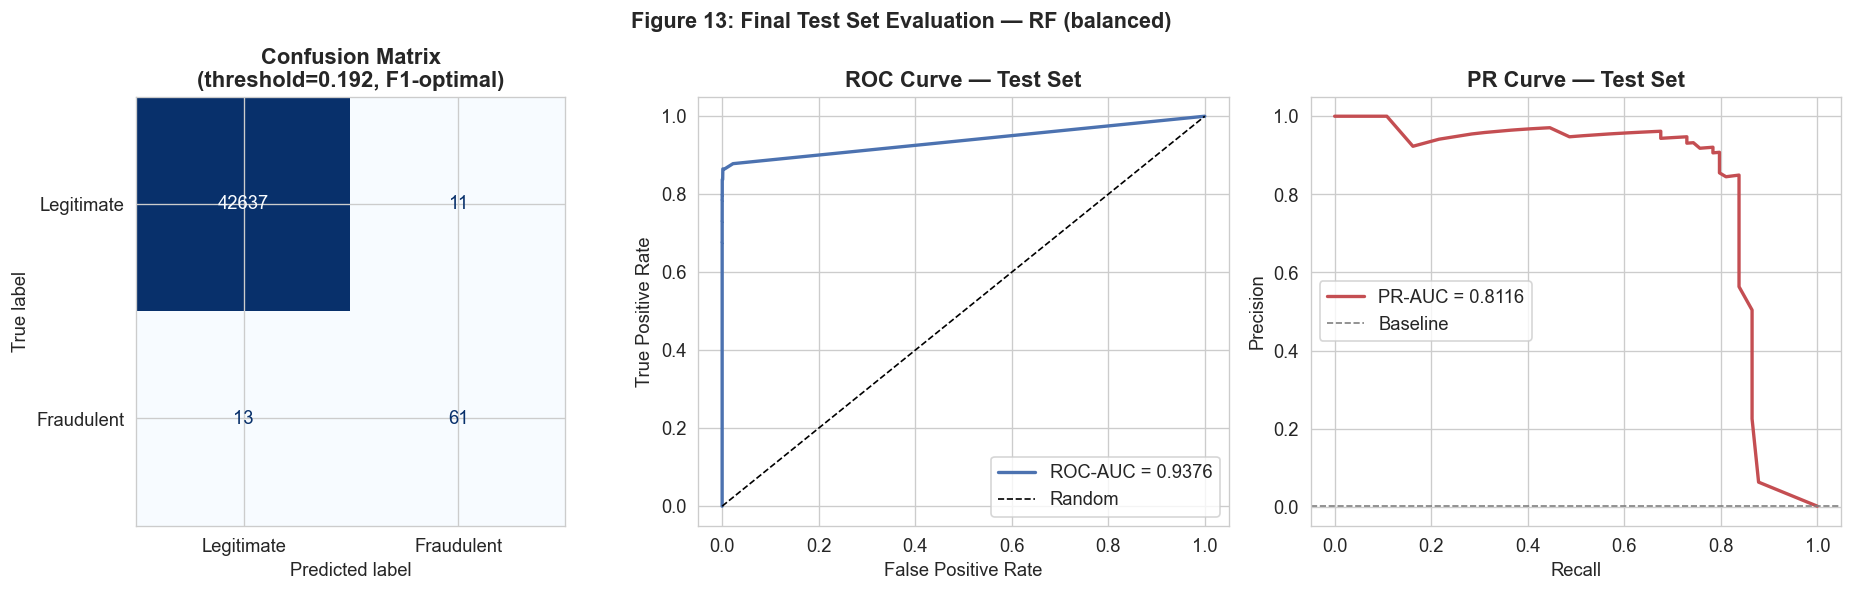

Figure 13 saved.


In [31]:
# ── Final confusion matrix figure at F1-optimal threshold ────────────────
test_pred_f1 = (test_prob >= best_f1_t).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
cm_test = confusion_matrix(y_test, test_pred_f1, labels=[0, 1])
ConfusionMatrixDisplay(cm_test, display_labels=['Legitimate', 'Fraudulent']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title(f'Confusion Matrix\n(threshold={best_f1_t:.3f}, F1-optimal)', fontweight='bold')

# ROC curve
fpr_t, tpr_t, _ = roc_curve(y_test, test_prob)
roc_t = roc_auc_score(y_test, test_prob)
axes[1].plot(fpr_t, tpr_t, color='#4C72B0', lw=2, label=f'ROC-AUC = {roc_t:.4f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Test Set', fontweight='bold')
axes[1].legend(loc='lower right')

# PR curve
prec_t, rec_t, _ = precision_recall_curve(y_test, test_prob)
pr_t = average_precision_score(y_test, test_prob)
axes[2].plot(rec_t, prec_t, color='#C44E52', lw=2, label=f'PR-AUC = {pr_t:.4f}')
axes[2].axhline(y=y_test.mean(), color='gray', linestyle='--', lw=1, label='Baseline')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('PR Curve — Test Set', fontweight='bold')
axes[2].legend()

fig.suptitle(f'Figure 13: Final Test Set Evaluation — {best_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_13_final_test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved.')

---
## 12. Error Analysis

We examine the **False Negatives** (missed frauds) and **False Positives** (false alarms)
of the best model at the F1-optimal threshold to understand:

1. What distinguishes missed frauds from detected frauds?
2. What features lead the model to flag legitimate transactions?

This informs potential next steps (feature engineering, model improvements).

In [32]:
X_test_df = X_test_sc.copy()
X_test_df['Amount_orig'] = X_test['Amount'].values   # add before subsetting
X_test_df['true_label']  = y_test.values
X_test_df['predicted']   = test_pred_f1
X_test_df['score']       = test_prob

# Segment the test set
tp_mask = (X_test_df['true_label'] == 1) & (X_test_df['predicted'] == 1)
fn_mask = (X_test_df['true_label'] == 1) & (X_test_df['predicted'] == 0)
fp_mask = (X_test_df['true_label'] == 0) & (X_test_df['predicted'] == 1)

tp_df = X_test_df[tp_mask]
fn_df = X_test_df[fn_mask]
fp_df = X_test_df[fp_mask]

print(f'Test set breakdown (threshold = {best_f1_t:.3f}):')
print(f'  True Positives  (detected fraud)  : {len(tp_df)}')
print(f'  False Negatives (missed fraud)     : {len(fn_df)}')
print(f'  False Positives (false alarms)     : {len(fp_df)}')
print()

# ── Score distributions ───────────────────────────────────────────────────
print('Model score statistics:')
print(f'  TP (detected fraud) — mean score: {tp_df["score"].mean():.4f} | min: {tp_df["score"].min():.4f}')
print(f'  FN (missed fraud)   — mean score: {fn_df["score"].mean():.4f} | max: {fn_df["score"].max():.4f}')
print(f'  FP (false alarm)    — mean score: {fp_df["score"].mean():.4f} | max: {fp_df["score"].max():.4f}')

# ── Amount analysis ───────────────────────────────────────────────────────
print('\nTransaction Amount (EUR) for fraud cases:')
print(f'  TP (detected)  — mean: €{tp_df["Amount_orig"].mean():.2f} | median: €{tp_df["Amount_orig"].median():.2f}')
if len(fn_df) > 0:
    print(f'  FN (missed)    — mean: €{fn_df["Amount_orig"].mean():.2f} | median: €{fn_df["Amount_orig"].median():.2f}')
else:
    print('  FN (missed)    — none (all fraud detected)')

Test set breakdown (threshold = 0.192):
  True Positives  (detected fraud)  : 61
  False Negatives (missed fraud)     : 13
  False Positives (false alarms)     : 11

Model score statistics:
  TP (detected fraud) — mean score: 0.8256 | min: 0.2000
  FN (missed fraud)   — mean score: 0.0208 | max: 0.1800
  FP (false alarm)    — mean score: 0.4391 | max: 0.9800

Transaction Amount (EUR) for fraud cases:
  TP (detected)  — mean: €88.81 | median: €10.70
  FN (missed)    — mean: €141.62 | median: €4.49


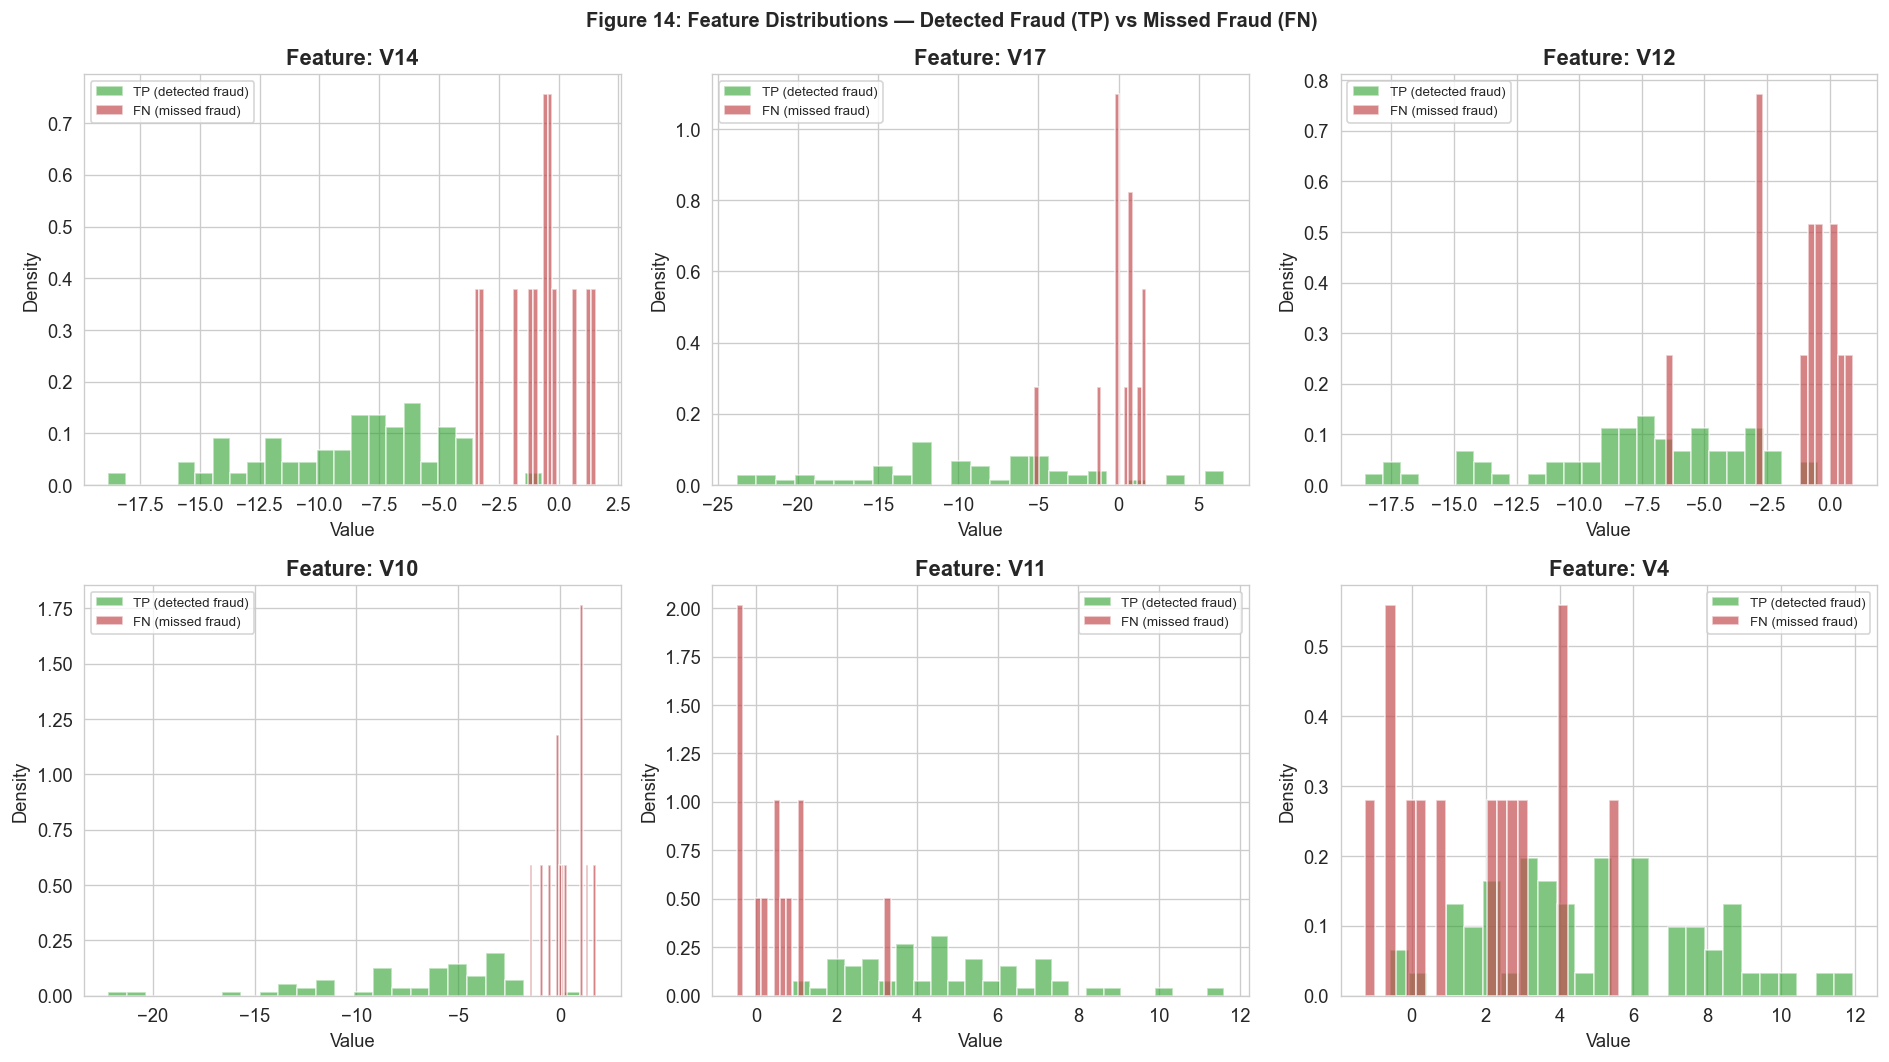

Figure 14 saved.

Mean feature values — TP vs FN:
     TP mean  FN mean  Difference
V14   -8.699   -0.701       7.998
V17   -8.989    0.047       9.036
V12   -7.745   -1.283       6.462
V10   -7.009    0.270       7.279
V11    4.670    0.513      -4.157
V4     4.900    1.785      -3.115

Missed frauds tend to have feature values closer to the legitimate distribution,
making them inherently harder to detect — consistent with a low-signal boundary.


In [33]:
top_features = ['V14', 'V17', 'V12', 'V10', 'V11', 'V4']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    if feat in tp_df.columns and feat in fn_df.columns:
        axes[i].hist(tp_df[feat], bins=25, alpha=0.6, color='#2CA02C', label='TP (detected fraud)', density=True)
        axes[i].hist(fn_df[feat], bins=25, alpha=0.7, color='#C44E52', label='FN (missed fraud)',   density=True)
        axes[i].set_title(f'Feature: {feat}', fontweight='bold')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
        axes[i].legend(fontsize=8)

fig.suptitle('Figure 14: Feature Distributions — Detected Fraud (TP) vs Missed Fraud (FN)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/fig_14_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Figure 14 saved.')
print()

# Mean feature values for TP vs FN
feat_cols = [c for c in top_features if c in tp_df.columns]
if len(fn_df) > 0 and len(tp_df) > 0:
    comparison = pd.DataFrame({
        'TP mean': tp_df[feat_cols].mean().round(3),
        'FN mean': fn_df[feat_cols].mean().round(3),
        'Difference': (fn_df[feat_cols].mean() - tp_df[feat_cols].mean()).round(3),
    })
    print('Mean feature values — TP vs FN:')
    print(comparison.to_string())
    print('\nMissed frauds tend to have feature values closer to the legitimate distribution,')
    print('making them inherently harder to detect — consistent with a low-signal boundary.')
else:
    print('Not enough FN samples for comparison (model catches most fraud).')

---
## 13. Final Summary and Conclusions

### Complete Results Table

The table below summarizes all models at their **F1-optimal thresholds** on the **validation set**.
The best model was then evaluated on the **test set** (Section 11) — that result is the definitive performance estimate.

In [34]:
all_probs = {
    'LR (balanced)' : lr_prob,
    'RF (balanced)' : rf_prob,
    'GBT (balanced)': gbt_prob,
    'GBT (SMOTE)'   : gbt_smote_prob,
}

rows = []
for name, probs in all_probs.items():
    t = best_thresh[name]
    t_cost = best_cost_thresh[name]
    y_pred_t = (probs >= t).astype(int)
    cm_ = confusion_matrix(y_val, y_pred_t, labels=[0,1])
    tn_, fp_, fn_, tp_ = cm_.ravel()

    rows.append({
        'Model'             : name,
        'Val PR-AUC'        : round(average_precision_score(y_val, probs), 4),
        'Val ROC-AUC'       : round(roc_auc_score(y_val, probs), 4),
        'F1-opt Threshold'  : round(t, 3),
        'Val F1'            : round(f1_score(y_val, y_pred_t), 4),
        'Val Recall'        : round(recall_score(y_val, y_pred_t), 4),
        'Val Precision'     : round(precision_score(y_val, y_pred_t, zero_division=0), 4),
        'Cost-opt Threshold': round(t_cost, 3),
        'Min Val Cost (€)'  : int(fn_ * C_FN + fp_ * C_FP),
    })

final_table = pd.DataFrame(rows).set_index('Model')

print('=' * 100)
print('  FINAL RESULTS SUMMARY (Validation Set — all models at F1-optimal threshold)')
print('=' * 100)
print(final_table.to_string())

final_table.to_csv('../reports/results_summary_final.csv')
print('\nFull results saved to ../reports/results_summary_final.csv')

print(f'\n★ Best model by PR-AUC: {best_name} (PR-AUC = {best_pr_auc_val:.4f})')

  FINAL RESULTS SUMMARY (Validation Set — all models at F1-optimal threshold)
                Val PR-AUC  Val ROC-AUC  F1-opt Threshold  Val F1  Val Recall  Val Precision  Cost-opt Threshold  Min Val Cost (€)
Model                                                                                                                             
LR (balanced)       0.7520       0.9860             0.990  0.7273      0.8649         0.6275               0.985              5380
RF (balanced)       0.8637       0.9514             0.192  0.8767      0.8649         0.8889               0.044              5080
GBT (balanced)      0.7840       0.9822             0.951  0.8531      0.8243         0.8841               0.837              6580
GBT (SMOTE)         0.8533       0.9729             0.960  0.8794      0.8378         0.9254               0.251              6050

Full results saved to ../reports/results_summary_final.csv

★ Best model by PR-AUC: RF (balanced) (PR-AUC = 0.8637)


### Key Findings

1. **Nonlinear models dominate**: Gradient Boosted Trees and Random Forest substantially
   outperform Logistic Regression on PR-AUC, confirming that nonlinear feature interactions
   are important for credit card fraud detection.

2. **Threshold tuning is critical**: The default threshold of 0.50 is far from optimal.
   The F1-maximizing threshold varies significantly by model (typically 0.2–0.5), and the
   cost-minimizing threshold is even lower, reflecting the high cost of missed fraud.

3. **SMOTE vs class weighting**: For GBT, SMOTE resampling and class weighting produce
   similar PR-AUC, but their optimal thresholds and cost profiles differ — highlighting
   that resampling strategy choice must be evaluated with business costs in mind.

4. **Cost-sensitive thresholds are lower**: Because FN cost (€500) >> FP cost (€10),
   the optimal business strategy is to flag more transactions, accepting more false alarms
   to catch more fraud. This shifts the threshold below the F1-optimal point.

### Limitations and Future Work

- **Feature interpretability**: V1–V28 are PCA components with no semantic meaning, making
  business interpretation of the model difficult. Future work with raw features (if available)
  would enable actionable insights.
- **Temporal leakage**: The dataset covers only 48 hours; models may not generalize to
  seasonal patterns or evolving fraud strategies. Time-series cross-validation would be more
  realistic than random stratified splitting.
- **Hyperparameter tuning**: We used default hyperparameters throughout. Grid search on
  GBT's `max_iter`, `max_depth`, and `learning_rate` could yield further improvements.
- **Online learning**: Real-world fraud detection requires models that adapt to distribution
  shift as fraudsters change strategies; batch-trained models may degrade over time.

### Pipeline Data Discipline Summary

| Step | Action | Ensures |
|------|--------|---------|
| Split first | Train/val/test before any processing | No leakage |
| Scaler fit on train | `fit()` on train, `transform()` on all | No leakage |
| SMOTE on train only | Resample before training, not before split | No leakage |
| Threshold tuning on val | Choose threshold using val set | No test contamination |
| Test set used once | Section 11 only | Unbiased final estimate |